**Angie Carolina Joya Duarte - 2322609**  

**Sheila Marcela Valencia Chito - 2243011**

## 1) Preparar el dataset

Importar librerías

In [16]:
import os
import pandas as pd
import numpy as np
import random
import math
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

Definir las semillas

In [17]:
semilla = 42
random.seed(semilla)
np.random.seed(semilla)
tf.random.set_seed(semilla)

Leer dataset seleccionado: ibm.us.csv

In [18]:
path = os.path.join(os.getcwd(), "ibm.us.csv")
dataset = pd.read_csv(path)
dataset.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,1962-01-02,6.4130,6.4130,6.3378,6.3378,467056,0
1,1962-01-03,6.3378,6.3963,6.3378,6.3963,350294,0
2,1962-01-04,6.3963,6.3963,6.3295,6.3295,314365,0
3,1962-01-05,6.3211,6.3211,6.1958,6.2041,440112,0
4,1962-01-08,6.2041,6.2041,6.0373,6.0870,655676,0


### a) Graficar el promedio

In [19]:
dataset["promedioDia"] = (dataset["High"]+dataset["Low"])/2
dataset["Date"] = pd.to_datetime(dataset["Date"])
dataset.head()

,Date,Open,High,Low,Close,Volume,OpenInt,promedioDia
0,1962-01-02,6.4130,6.4130,6.3378,6.3378,467056,0,6.37540
1,1962-01-03,6.3378,6.3963,6.3378,6.3963,350294,0,6.36705
2,1962-01-04,6.3963,6.3963,6.3295,6.3295,314365,0,6.36290
3,1962-01-05,6.3211,6.3211,6.1958,6.2041,440112,0,6.25845
4,1962-01-08,6.2041,6.2041,6.0373,6.0870,655676,0,6.12070


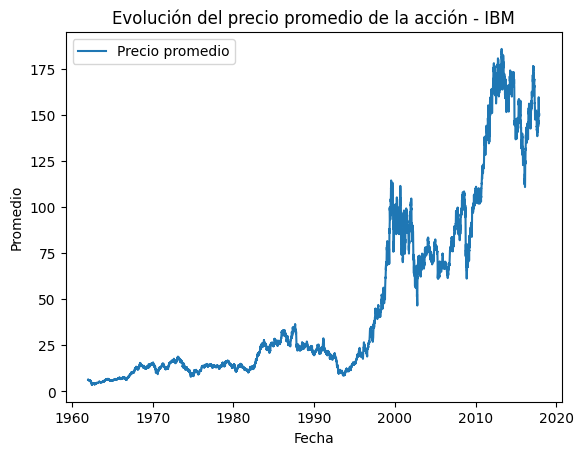

In [20]:
plt.plot(dataset["Date"], dataset["promedioDia"], label = "Precio promedio")
plt.title("Evolución del precio promedio de la acción - IBM")
plt.xlabel("Fecha")
plt.ylabel("Promedio")
plt.legend()
plt.show()

### b) Dividir los datos

In [21]:
#70% train, 15% validation, 15% test
n = len(dataset)

train = dataset[:int(n*0.7)][["promedioDia"]].to_numpy()
validation = dataset[int(n*0.7):int(n*0.85)][["promedioDia"]].to_numpy()
test = dataset[int(n*0.85):][["promedioDia"]].to_numpy()

print("Conjunto de entrenamiento: ",train[:5])
print("Conjunto de validación: ",validation[:5])
print("Conjunto de prueba: ",test[:5])

Conjunto de entrenamiento:  [[6.3754 ]
 [6.36705]
 [6.3629 ]
 [6.25845]
 [6.1207 ]]
Conjunto de validación:  [[96.151 ]
 [96.9425]
 [94.351 ]
 [94.384 ]
 [96.2135]]
Conjunto de prueba:  [[87.6125]
 [88.094 ]
 [85.8565]
 [84.6285]
 [84.332 ]]


### c) Normalizar los datos

Normalizar los datos

In [22]:
#Hallar la media y desviación del entrenamiento
media = train.mean()
desvest  = train.std()

#Normalizar los 3 subconjuntos respecto a los valores calculados
train = (train - media) / desvest
validation   = (validation   - media) / desvest
test  = (test  - media) / desvest

Creación de ventanas

In [23]:
#Ventanas de 15 días con muestras diarias
sampling_rate = 1
sequence_length = 15
delay = 1 
batch_size = 256

Preparar los dataset de acuerdo a la ventana de tiempo

In [24]:
train2D = train.reshape(-1, 1)
validation2D = validation.reshape(-1, 1)
test2D = test.reshape(-1, 1)

datasetTrain = keras.utils.timeseries_dataset_from_array(
  data = train2D[:-delay],
  targets=train2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=sequence_length,
  shuffle=True,
  batch_size=batch_size,
  start_index=0
  )

datasetValidation = keras.utils.timeseries_dataset_from_array(
  data = validation2D[:-delay],
  targets=validation2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=sequence_length,
  shuffle=False,
  batch_size=batch_size,
  start_index=0
  )

datasetTest = keras.utils.timeseries_dataset_from_array(
  data = test2D[:-delay],
  targets=test2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=sequence_length,
  shuffle=False,
  batch_size=batch_size,
  start_index=0
  )

Funciones auxiliares para graficar

In [25]:
def graficaeMAE(history, titulo, ax=None):
  if ax is None:
    ax = plt.gca()

  loss = history.history["mae"]
  val_loss = history.history["val_mae"]
  epochs = range(1, len(loss) + 1)

  ax.plot(epochs, loss, "o-", label="MAE Entrenamiento")
  ax.plot(epochs, val_loss, "-", label="MAE Validación")
  ax.set_title(titulo)
  ax.set_xlabel("Época")
  ax.set_ylabel("MAE")
  ax.legend()

def graficarPrediccion(prediccion, y, titulo, ax=None):
  rango=(20, 70)
  
  if ax is None:
    ax = plt.gca()
        
  start, end = rango
  ax.plot(y[start:end], label="Valor Real")
  ax.plot(prediccion[start:end], label="Predicción")
  ax.set_title(titulo)
  ax.set_xlabel("Índice")
  ax.set_ylabel("Valor")
  ax.legend()

## 2) Modelo LSTM 

Definir arquitectura de la red

In [26]:
cantNeuronas = 16
epocas = 20

In [27]:
inputs = keras.Input(shape=(sequence_length, 1))
x = layers.LSTM(cantNeuronas)(inputs) 
outputs = layers.Dense(1)(x)
LSTMBase = keras.Model(inputs, outputs)

Realizar el entrenamiento

In [28]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]
LSTMBase.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

history = LSTMBase.fit(
    datasetTrain,
    epochs=epocas,
    validation_data=datasetValidation,
    callbacks=callbacks
)

print(f"MAE de las pruebas - LSTM: {LSTMBase.evaluate(datasetTest)[1]:.2f}")

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.3985 - mae: 0.2956 - val_loss: 1.6480 - val_mae: 1.1375
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1209 - mae: 0.1377 - val_loss: 0.4108 - val_mae: 0.4562
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0394 - mae: 0.0875 - val_loss: 0.1420 - val_mae: 0.3287
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0115 - mae: 0.0537 - val_loss: 0.0379 - val_mae: 0.1511
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0062 - mae: 0.0433 - val_loss: 0.0209 - val_mae: 0.1045
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0050 - mae: 0.0388 - val_loss: 0.0183 - val_mae: 0.0959
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0048 - mae: 0.0373 - val_loss: 0.0173 - val_mae: 0.0939
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0043 - mae: 0.0360 - val_loss: 0.0186 - val_mae: 0.1040
Epoch 9/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.004

Evaluar los resultados

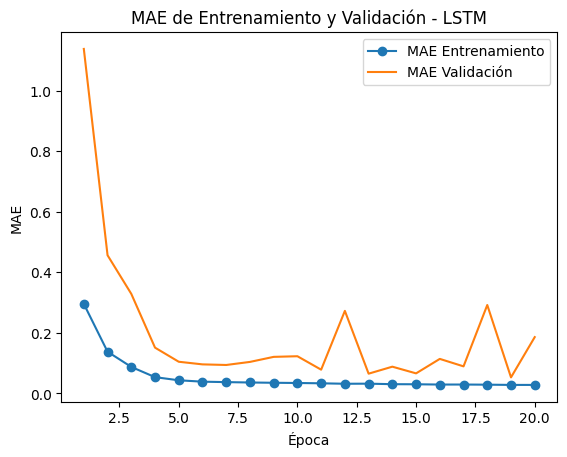

In [29]:
graficaeMAE(history, "MAE de Entrenamiento y Validación - LSTM")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


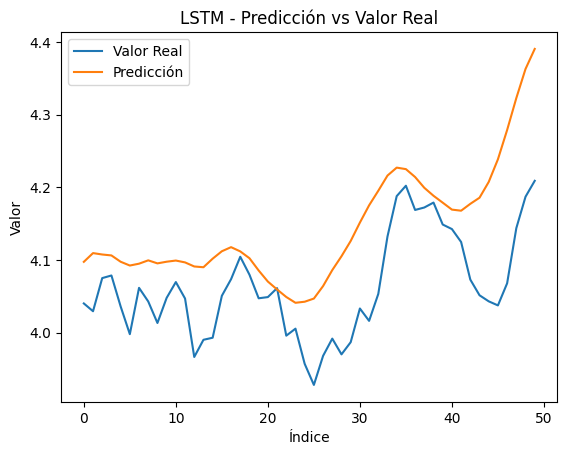

In [30]:
prediccion = LSTMBase.predict(datasetTest)
y = np.concatenate([y for x, y in datasetTest], axis=0)

graficarPrediccion(prediccion, y, "LSTM - Predicción vs Valor Real")

Modificando el número de neuronas

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
MAE de prueba (5 neuronas): 2.2098
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
MAE de prueba (15 neuronas): 1.9499
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
MAE de prueba (30 neuronas): 2.1087


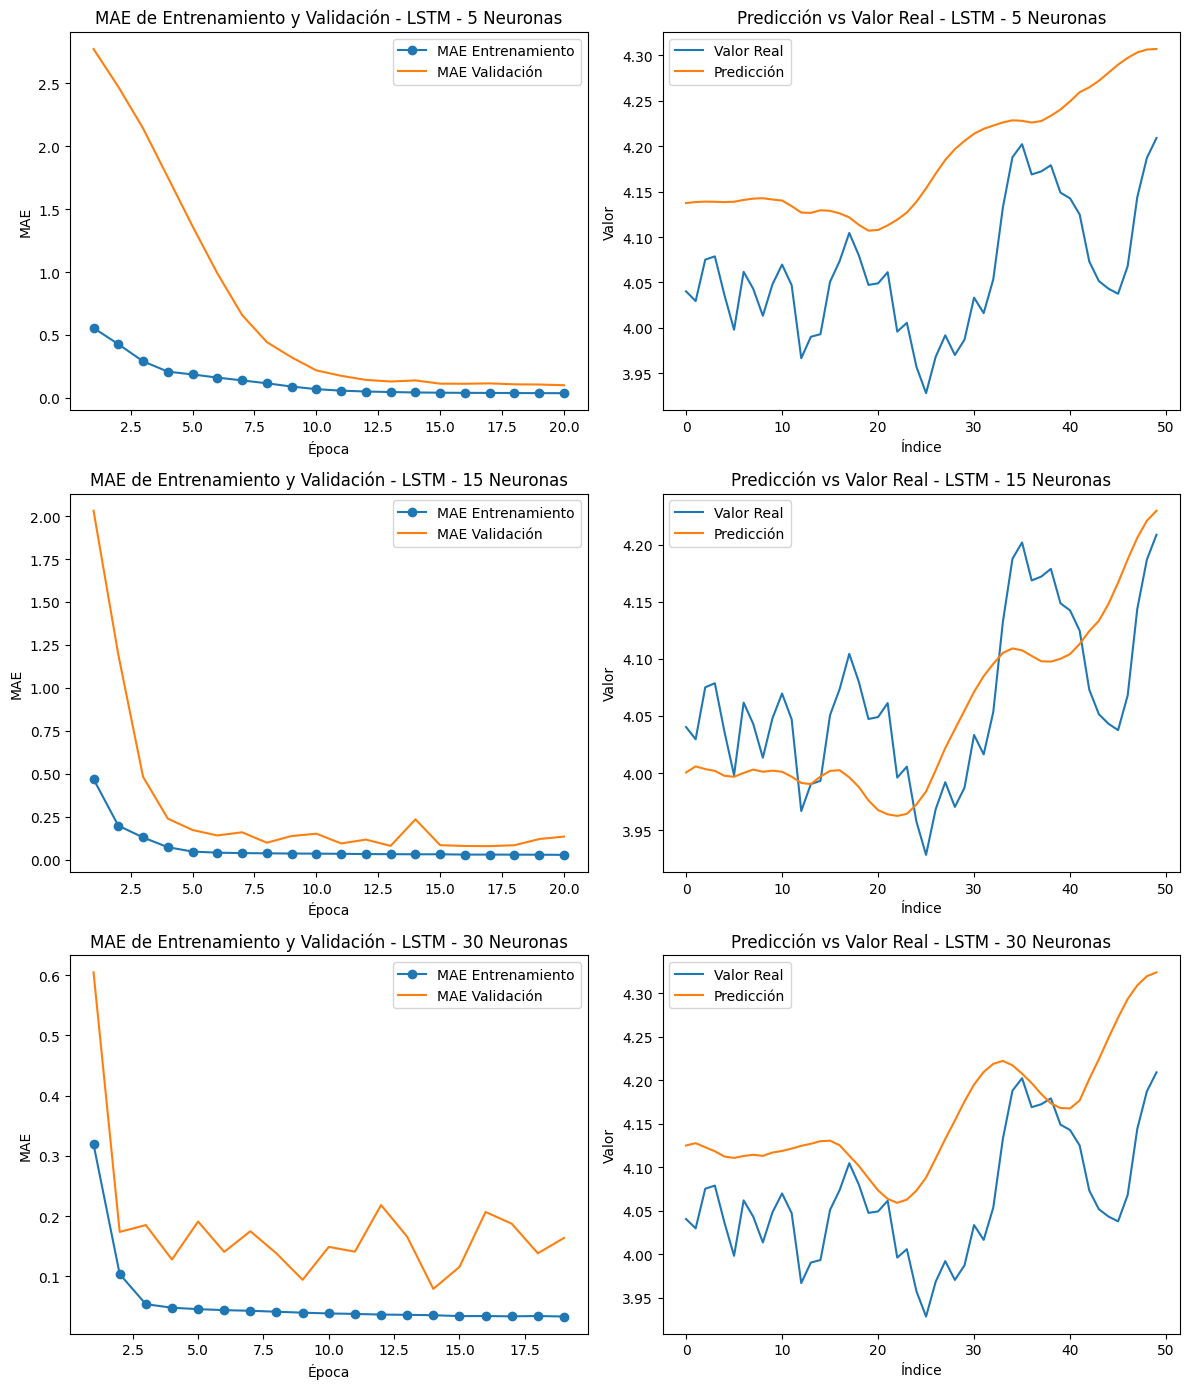

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

cantNeuronasLSTM = [5,15,30]

for i, n in enumerate(cantNeuronasLSTM):
  #Limpiar sesión
  tf.keras.backend.clear_session()
  
  #Crear el modelo 
  inputs = keras.Input(shape=(sequence_length, 1))
  x = layers.LSTM(n)(inputs)
  outputs = layers.Dense(1)(x)
  modelo = keras.Model(inputs, outputs)
  
  #Entrenar el modelo
  cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
  modelo.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])    
  
  history = modelo.fit(
    datasetTrain,
    epochs=epocas,
    validation_data=datasetValidation,
    callbacks=cb,
    verbose=0   
  )
  
  #Evaluar el modelo
  mae = modelo.evaluate(datasetTest, verbose=0)[1]
  pred = modelo.predict(datasetTest)  
  graficaeMAE(history, f"MAE de Entrenamiento y Validación - LSTM - {n} Neuronas", axes[i][0])
  graficarPrediccion(pred, y, f"Predicción vs Valor Real - LSTM - {n} Neuronas", axes[i][1])

  print(f"MAE de prueba ({n} neuronas): {mae:.4f}")

plt.tight_layout()
plt.show()

Modificando el número de iteraciones

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
MAE de prueba (15 Épocas): 2.4354
Épocas realmente usadas: 15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
MAE de prueba (50 Épocas): 2.0877
Épocas realmente usadas: 48
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
MAE de prueba (100 Épocas): 2.3242
Épocas realmente usadas: 43


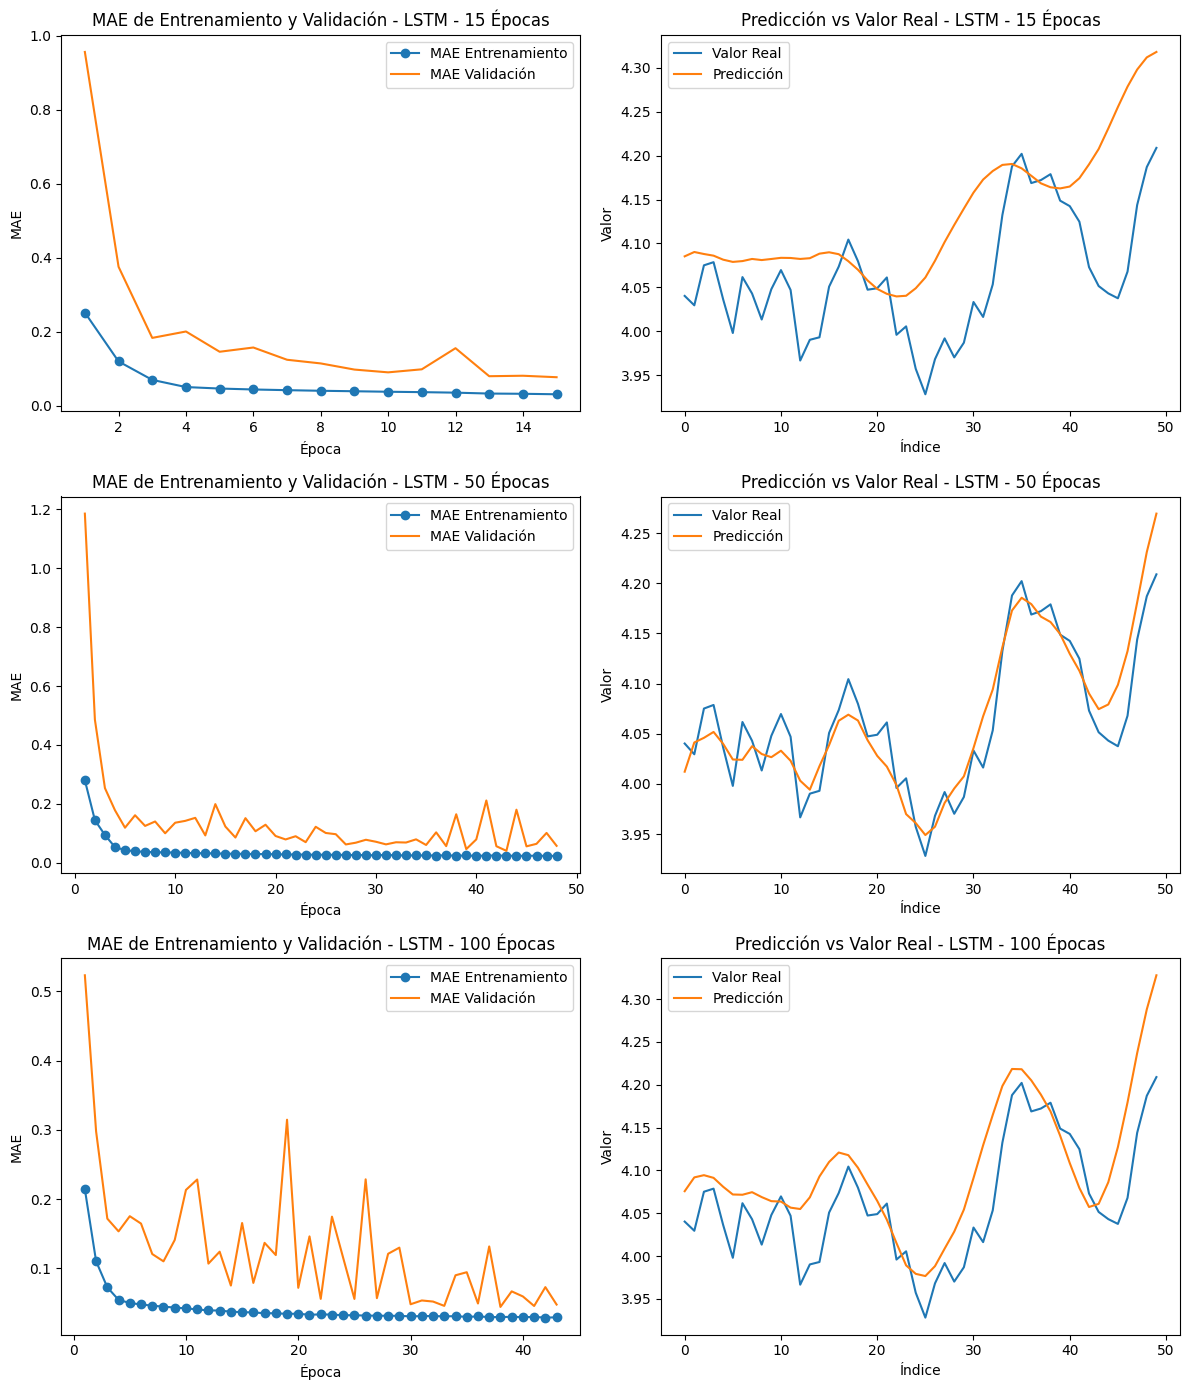

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

epocasLSTM = [15,50,100]

for i, n in enumerate(epocasLSTM):
  #Limpiar sesión
  tf.keras.backend.clear_session()
  
  #Crear el modelo 
  inputs = keras.Input(shape=(sequence_length, 1))
  x = layers.LSTM(15)(inputs)
  outputs = layers.Dense(1)(x)
  modelo = keras.Model(inputs, outputs)
  
  #Entrenar el modelo
  cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
  modelo.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])    
  
  history = modelo.fit(
    datasetTrain,
    epochs=n,
    validation_data=datasetValidation,
    callbacks=cb,
    verbose=0   
  )
  
  #Evaluar el modelo
  mae = modelo.evaluate(datasetTest, verbose=0)[1]
  pred = modelo.predict(datasetTest)  
  graficaeMAE(history, f"MAE de Entrenamiento y Validación - LSTM - {n} Épocas", axes[i][0])
  graficarPrediccion(pred, y, f"Predicción vs Valor Real - LSTM - {n} Épocas", axes[i][1])

  print(f"MAE de prueba ({n} Épocas): {mae:.4f}")
  print("Épocas realmente usadas:", len(history.history["loss"]))

plt.tight_layout()
plt.show()

Cambiando la ventana

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
MAE de prueba (Ventana de 3 días): 0.9321
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
MAE de prueba (Ventana de 7 días): 1.5832
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
MAE de prueba (Ventana de 30 días): 2.3270
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
MAE de prueba (Ventana de 60 días): 2.7378


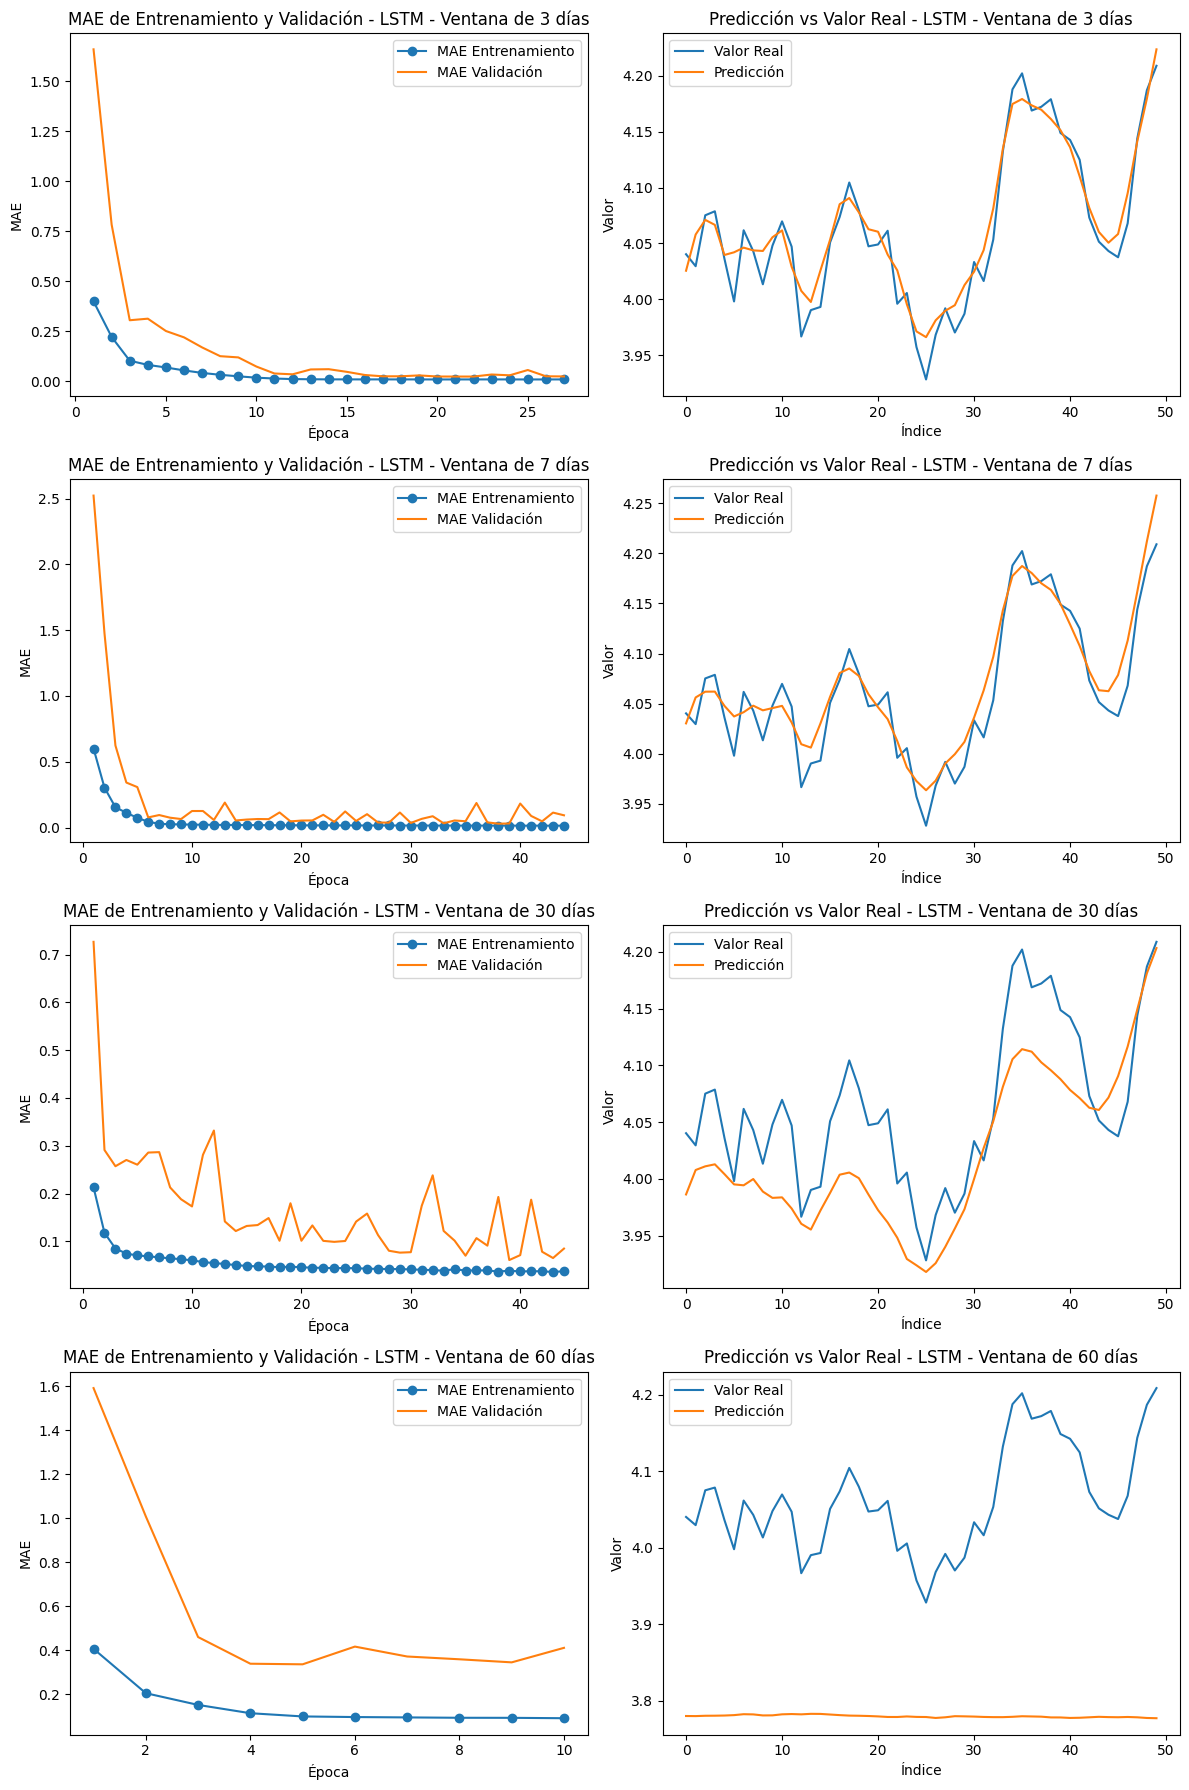

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12, 18))

sequenceLSTM = [3,7,30,60]

for i, n in enumerate(sequenceLSTM):
  #Limpiar sesión
  tf.keras.backend.clear_session()
  
  #Definir los nuevo dataset
  datasetTrainLSTM = keras.utils.timeseries_dataset_from_array(
    data = train2D[:-delay],
    targets=train2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=n,
    shuffle=True,
    batch_size=batch_size,
    start_index=0
  )
  
  datasetValidationLSTM = keras.utils.timeseries_dataset_from_array(
    data = validation2D[:-delay],
    targets=validation2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=n,
    shuffle=False,
    batch_size=batch_size,
    start_index=0
  )

  datasetTestLSTM = keras.utils.timeseries_dataset_from_array(
    data = test2D[:-delay],
    targets=test2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=n,
    shuffle=False,
    batch_size=batch_size,
    start_index=0
  )
  
  #Crear el modelo 
  inputs = keras.Input(shape=(n, 1))
  x = layers.LSTM(15)(inputs)
  outputs = layers.Dense(1)(x)
  modelo = keras.Model(inputs, outputs)
  
  #Entrenar el modelo
  cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
  modelo.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])    
  
  history = modelo.fit(
    datasetTrainLSTM,
    epochs=50,
    validation_data=datasetValidationLSTM,
    callbacks=cb,
    verbose=0   
  )
  
  #Evaluar el modelo
  mae = modelo.evaluate(datasetTestLSTM, verbose=0)[1]
  y = np.concatenate([y for x, y in datasetTestLSTM], axis=0)
  pred = modelo.predict(datasetTestLSTM)  
  graficaeMAE(history, f"MAE de Entrenamiento y Validación - LSTM - Ventana de {n} días", axes[i][0])
  graficarPrediccion(pred, y, f"Predicción vs Valor Real - LSTM - Ventana de {n} días", axes[i][1])

  print(f"MAE de prueba (Ventana de {n} días): {mae:.4f}")

plt.tight_layout()
plt.show()

Cambiando el Batch Size

132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
MAE de prueba (Batch Size 16): 0.8677
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
MAE de prueba (Batch Size 32): 0.8656
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
MAE de prueba (Batch Size 64): 0.9859
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
MAE de prueba (Batch Size 128): 1.1119


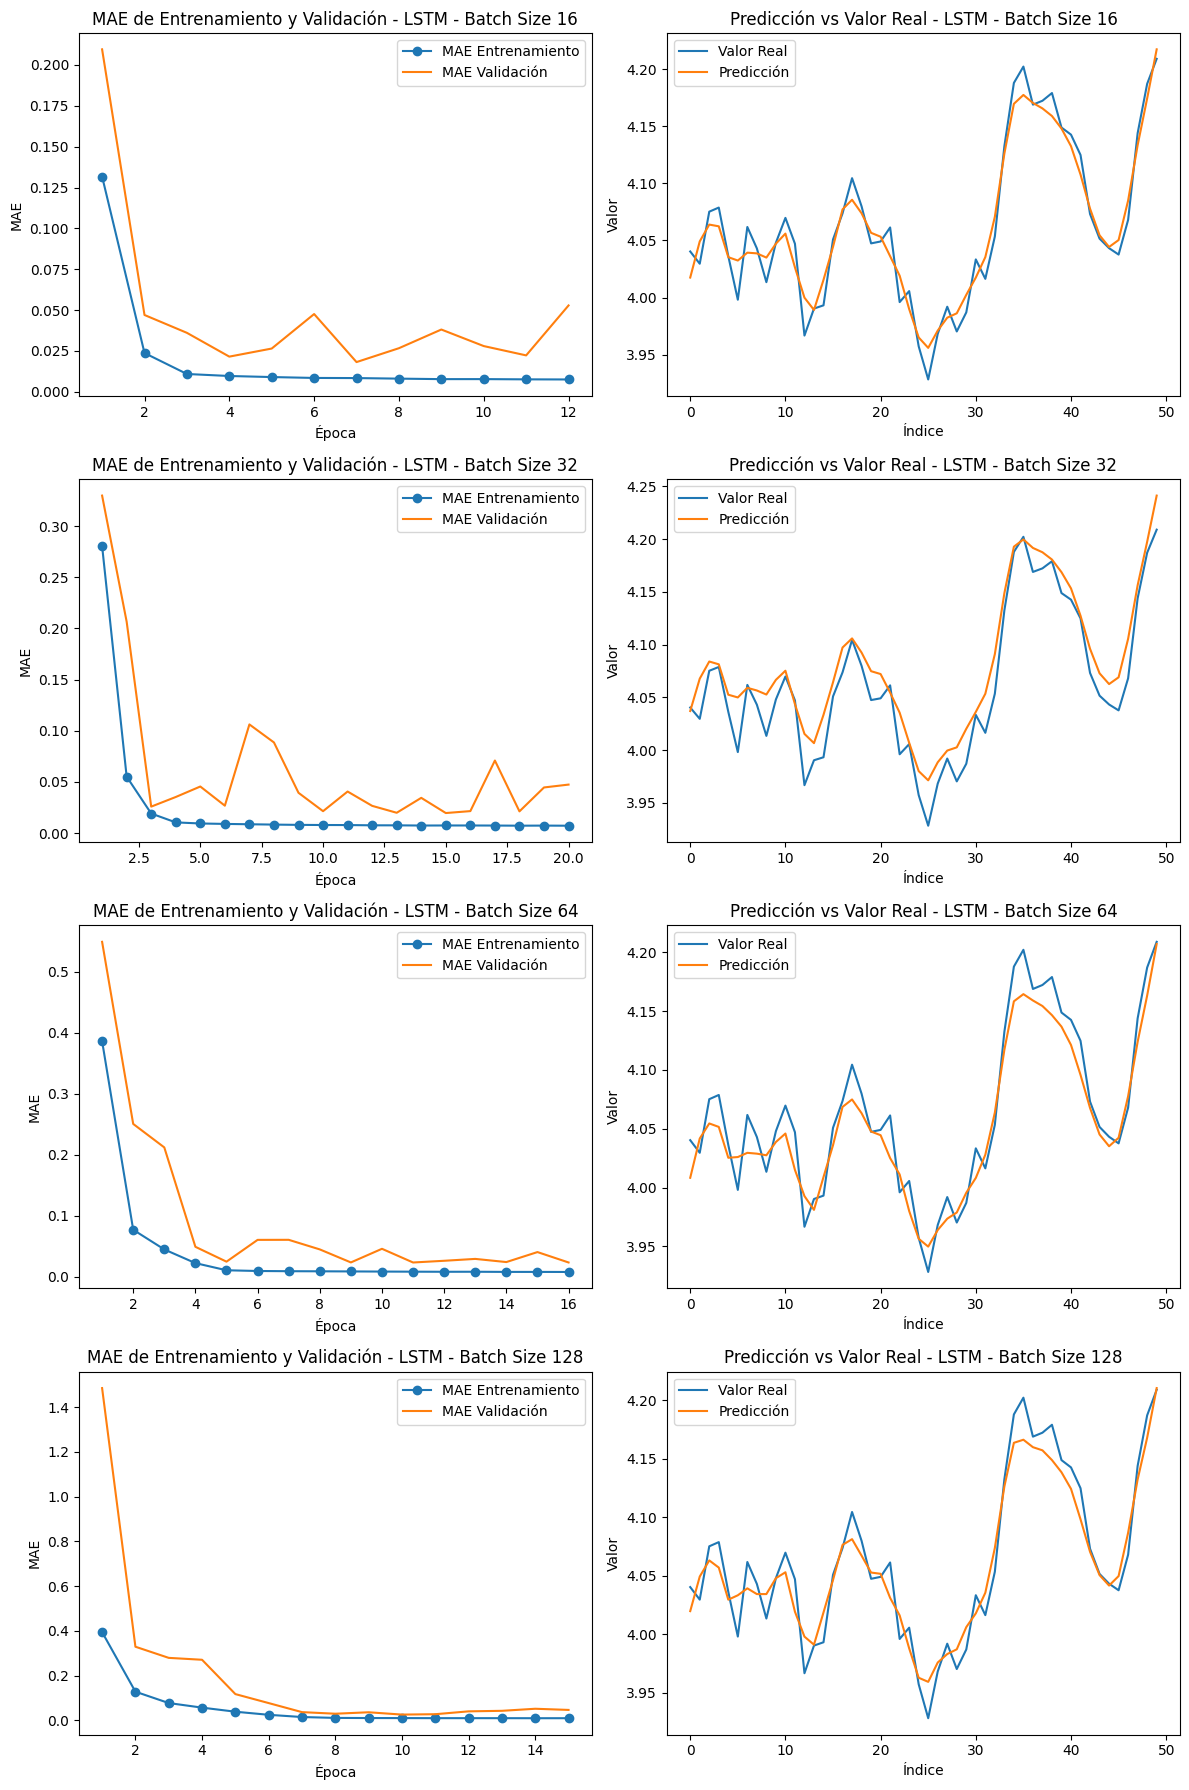

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12, 18))

batchLSTM = [16,32,64,128]

for i, n in enumerate(batchLSTM):
  #Limpiar sesión
  tf.keras.backend.clear_session()
  
  #Definir los nuevo dataset
  datasetTrainLSTM = keras.utils.timeseries_dataset_from_array(
    data = train2D[:-delay],
    targets=train2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=3,
    shuffle=True,
    batch_size=n,
    start_index=0
  )
  
  datasetValidationLSTM = keras.utils.timeseries_dataset_from_array(
    data = validation2D[:-delay],
    targets=validation2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=3,
    shuffle=False,
    batch_size=n,
    start_index=0
  )

  datasetTestLSTM = keras.utils.timeseries_dataset_from_array(
    data = test2D[:-delay],
    targets=test2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=3,
    shuffle=False,
    batch_size=n,
    start_index=0
  )
  
  #Crear el modelo 
  inputs = keras.Input(shape=(3, 1))
  x = layers.LSTM(15)(inputs)
  outputs = layers.Dense(1)(x)
  modelo = keras.Model(inputs, outputs)
  
  #Entrenar el modelo
  cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
  modelo.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])    
  
  history = modelo.fit(
    datasetTrainLSTM,
    epochs=50,
    validation_data=datasetValidationLSTM,
    callbacks=cb,
    verbose=0   
  )
  
  #Evaluar el modelo
  mae = modelo.evaluate(datasetTestLSTM, verbose=0)[1]
  y = np.concatenate([y for x, y in datasetTestLSTM], axis=0)
  pred = modelo.predict(datasetTestLSTM)  
  graficaeMAE(history, f"MAE de Entrenamiento y Validación - LSTM - Batch Size {n}", axes[i][0])
  graficarPrediccion(pred, y, f"Predicción vs Valor Real - LSTM - Batch Size {n}", axes[i][1])

  print(f"MAE de prueba (Batch Size {n}): {mae:.4f}")

plt.tight_layout()
plt.show()

Habilitando y deshabilitando el recurrent dropout

In [35]:
datasetTrainLSTM = keras.utils.timeseries_dataset_from_array(
  data = train2D[:-delay],
  targets=train2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=3,
  shuffle=True,
  batch_size=32,
  start_index=0
  )

datasetValidationLSTM = keras.utils.timeseries_dataset_from_array(
  data = validation2D[:-delay],
  targets=validation2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=3,
  shuffle=False,
  batch_size=32,
  start_index=0
  )

datasetTestLSTM = keras.utils.timeseries_dataset_from_array(
  data = test2D[:-delay],
  targets=test2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=3,
  shuffle=False,
  batch_size=32,
  start_index=0
  )

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
MAE de prueba (Recurrent Dropout 0): 1.2563
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
MAE de prueba (Recurrent Dropout 0.3): 0.7546
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
MAE de prueba (Recurrent Dropout 0.5): 0.8610


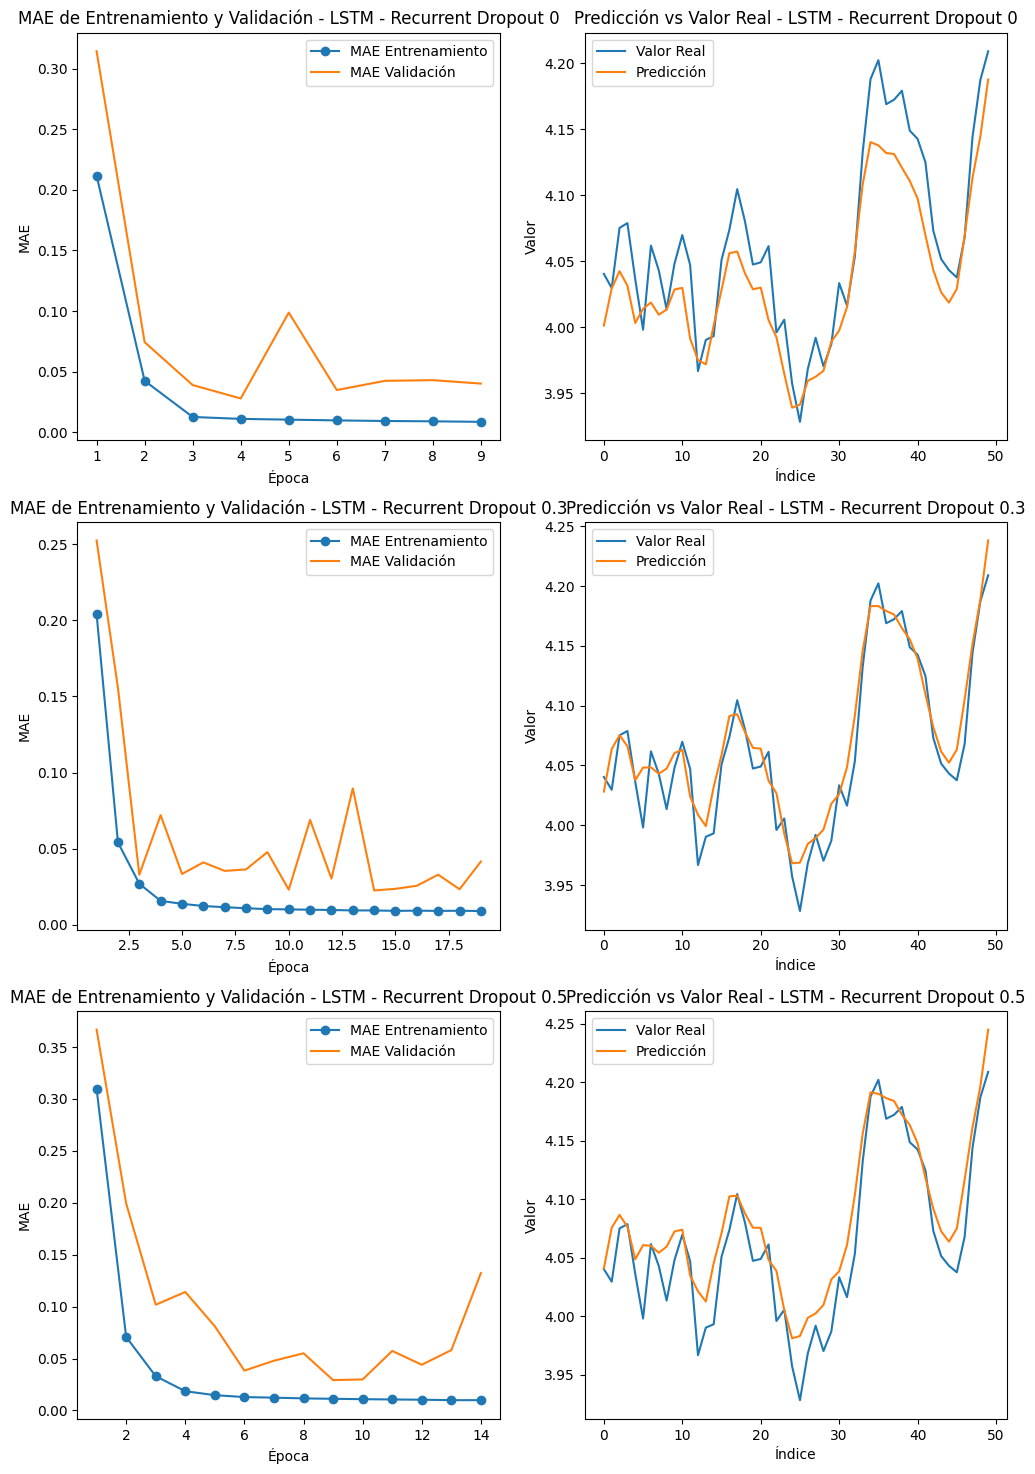

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(12, 18))

recurrentDropoutLSTM = [0, 0.3, 0.5]

for i, n in enumerate(recurrentDropoutLSTM):
  #Limpiar sesión
  tf.keras.backend.clear_session()
  
  #Crear el modelo 
  inputs = keras.Input(shape=(3, 1))
  x = layers.LSTM(15, recurrent_dropout=n)(inputs)
  outputs = layers.Dense(1)(x)
  modelo = keras.Model(inputs, outputs)
    
  cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
  modelo.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])    
  
  history = modelo.fit(
    datasetTrainLSTM,
    epochs=50,
    validation_data=datasetValidationLSTM,
    callbacks=cb,
    verbose=0   
  )
  
  #Evaluar el modelo
  mae = modelo.evaluate(datasetTestLSTM, verbose=0)[1]
  y = np.concatenate([y for x, y in datasetTestLSTM], axis=0)
  pred = modelo.predict(datasetTestLSTM)  
  graficaeMAE(history, f"MAE de Entrenamiento y Validación - LSTM - Recurrent Dropout {n}", axes[i][0])
  graficarPrediccion(pred, y, f"Predicción vs Valor Real - LSTM - Recurrent Dropout {n}", axes[i][1])

  print(f"MAE de prueba (Recurrent Dropout {n}): {mae:.4f}")

Diferentes optimizadores

66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step
MAE de prueba (Optimizador adam): 0.6869
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
MAE de prueba (Optimizador rmsprop): 0.8192
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
MAE de prueba (Optimizador nadam): 0.9730


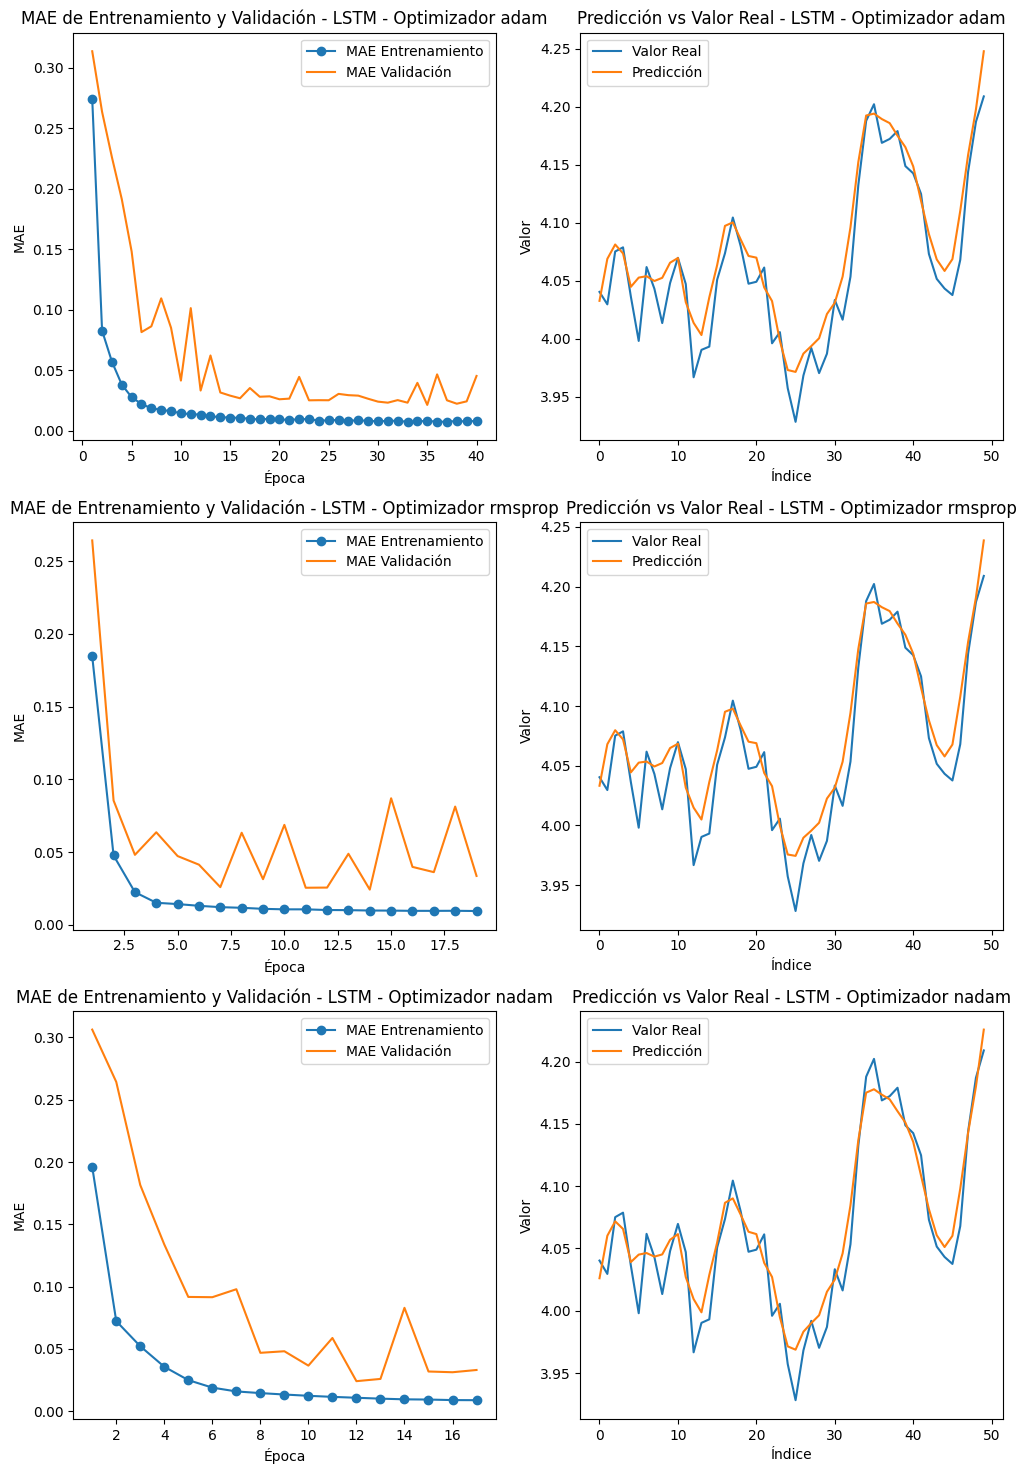

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(12, 18))

optimizerLSTM = ["adam", "rmsprop", "nadam"]

for i, n in enumerate(optimizerLSTM):
  #Limpiar sesión
  tf.keras.backend.clear_session()
  
  #Crear el modelo 
  inputs = keras.Input(shape=(3, 1))
  x = layers.LSTM(15, recurrent_dropout=0.3)(inputs)
  outputs = layers.Dense(1)(x)
  modelo = keras.Model(inputs, outputs)
    
  cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
  modelo.compile(optimizer=n, loss="mse", metrics=["mae"])    
  
  history = modelo.fit(
    datasetTrainLSTM,
    epochs=50,
    validation_data=datasetValidationLSTM,
    callbacks=cb,
    verbose=0   
  )
  
  #Evaluar el modelo
  mae = modelo.evaluate(datasetTestLSTM, verbose=0)[1]
  y = np.concatenate([y for x, y in datasetTestLSTM], axis=0)
  pred = modelo.predict(datasetTestLSTM)  
  graficaeMAE(history, f"MAE de Entrenamiento y Validación - LSTM - Optimizador {n}", axes[i][0])
  graficarPrediccion(pred, y, f"Predicción vs Valor Real - LSTM - Optimizador {n}", axes[i][1])

  print(f"MAE de prueba (Optimizador {n}): {mae:.4f}")

**Configuración con mejores resultados**

Cantidad de Neuronas = 15

Épocas = Entre 30 y 50 (early stopping)

Sequence Length = 3 días

Batch Size = 32

Recurrent Dropout = 0.3

Optimizador = Adam

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
MAE de prueba - Mejores Resultados): 0.7162


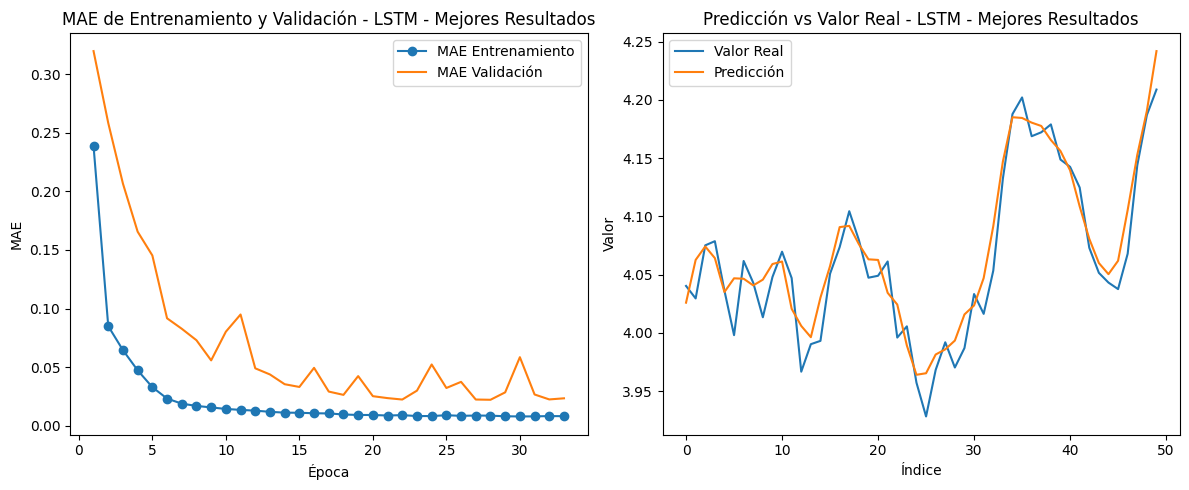

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Crear el modelo 
inputs = keras.Input(shape=(3, 1))
x = layers.LSTM(15, recurrent_dropout=0.3)(inputs)
outputs = layers.Dense(1)(x)
modelo = keras.Model(inputs, outputs)

#Entrenar el modelo
cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
modelo.compile(optimizer="adam", loss="mse", metrics=["mae"])    

history = modelo.fit(
  datasetTrainLSTM,
  epochs=50,
  validation_data=datasetValidationLSTM,
  callbacks=cb,
  verbose=0   
)

#Evaluar el modelo
mae = modelo.evaluate(datasetTestLSTM, verbose=0)[1]
pred = modelo.predict(datasetTestLSTM)  
y = np.concatenate([y for x, y in datasetTestLSTM], axis=0)
graficaeMAE(history, f"MAE de Entrenamiento y Validación - LSTM - Mejores Resultados", axes[0])
graficarPrediccion(pred, y, f"Predicción vs Valor Real - LSTM - Mejores Resultados", axes[1])

print(f"MAE de prueba - Mejores Resultados): {mae:.4f}")

plt.tight_layout()
plt.show()

## 3) Modelo GRU

Definir la arquitectura

In [62]:
inputsGRU = keras.Input(shape=(sequence_length, 1))
xGRU = layers.GRU(64)(inputsGRU) 
outputsGRU = layers.Dense(1)(xGRU)
GRUBase = keras.Model(inputsGRU, outputsGRU)

Entrenar el modelo

In [63]:
GRUBase.compile(optimizer="adam", loss="mse", metrics=["mae"])
callbacksGRU = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

historyGRU = GRUBase.fit(
    datasetTrain,
    epochs=20,
    validation_data=datasetValidation,
    callbacks=callbacksGRU
)

print(f"MAE de las pruebas - GRU: {GRUBase.evaluate(datasetTest)[1]:.2f}")

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.2208 - mae: 0.2287 - val_loss: 0.0729 - val_mae: 0.2075
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0138 - mae: 0.0555 - val_loss: 0.0528 - val_mae: 0.1806
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0097 - mae: 0.0514 - val_loss: 0.0455 - val_mae: 0.1715
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0085 - mae: 0.0506 - val_loss: 0.0425 - val_mae: 0.1679
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0078 - mae: 0.0496 - val_loss: 0.0359 - val_mae: 0.1510
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0071 - mae: 0.0484 - val_loss: 0.0314 - val_mae: 0.1404
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0063 - mae: 0.0463 - val_loss: 0.0283 - val_mae: 0.1344
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0053 - mae: 0.0436 - val_loss: 0.0174 - val_mae: 0.0967
Epoch 9/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.004

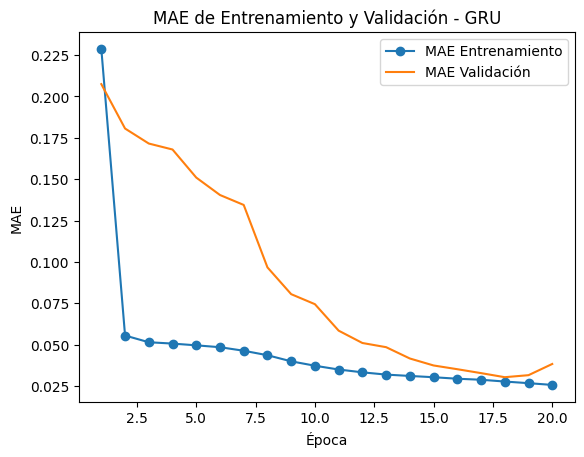

In [64]:
graficaeMAE(historyGRU, "MAE de Entrenamiento y Validación - GRU")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


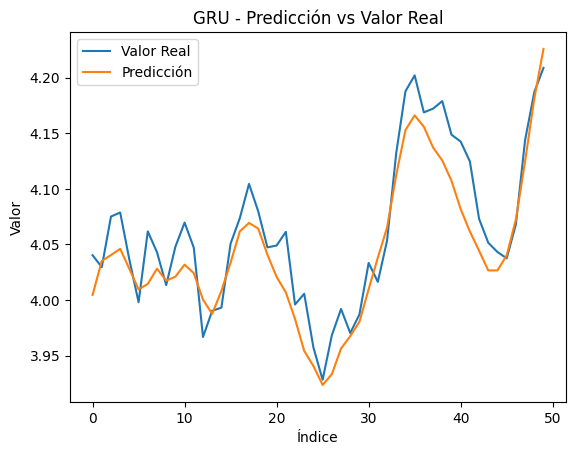

In [65]:
prediccionGRU = GRUBase.predict(datasetTest)
y = np.concatenate([y for x, y in datasetTest], axis=0) 

graficarPrediccion(prediccionGRU, y, "GRU - Predicción vs Valor Real")

### Pruebas con diferente número de neuronas:

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
MAE de prueba (15 neuronas): 1.9205
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
MAE de prueba (30 neuronas): 1.4902
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
MAE de prueba (70 neuronas): 1.4081


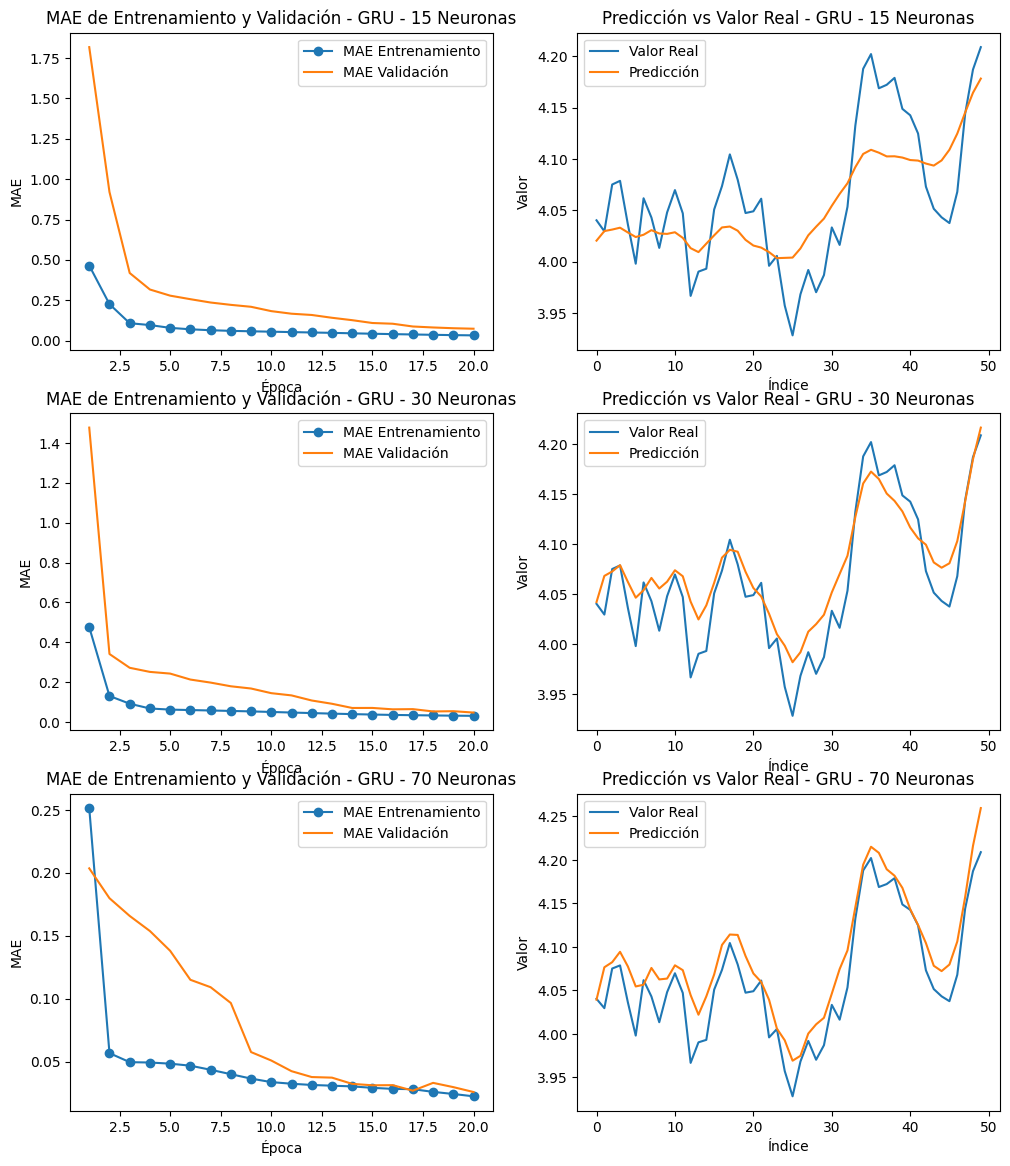

In [66]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

cantNeuronasGRU = [15,30, 70]

for i, n in enumerate(cantNeuronasGRU):
  #Limpiar sesión
  tf.keras.backend.clear_session()
  
  #Crear el modelo 
  inputs = keras.Input(shape=(sequence_length, 1))
  x = layers.GRU(n)(inputs)
  outputs = layers.Dense(1)(x)
  modeloGRU = keras.Model(inputs, outputs)
  
  #Entrenar el modelo
  callbacksGRU = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
  ]
  modeloGRU.compile(optimizer="adam", loss="mse", metrics=["mae"])    
  
  historyGRU = modeloGRU.fit(
    datasetTrain,
    epochs=20,
    validation_data=datasetValidation,
    callbacks=callbacksGRU,
    verbose=0   
  )
  
  #Evaluar el modelo
  maeGRU = modeloGRU.evaluate(datasetTest, verbose=0)[1]
  predGRU = modeloGRU.predict(datasetTest)  
  graficaeMAE(historyGRU, f"MAE de Entrenamiento y Validación - GRU - {n} Neuronas", axes[i][0])
  graficarPrediccion(predGRU, y, f"Predicción vs Valor Real - GRU - {n} Neuronas", axes[i][1])

  print(f"MAE de prueba ({n} neuronas): {maeGRU:.4f}")


### Pruebas con diferente número de iteraciones

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
MAE de prueba (15 iteraciones): 1.0743
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
MAE de prueba (25 iteraciones): 0.9258
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
MAE de prueba (30 iteraciones): 0.8072


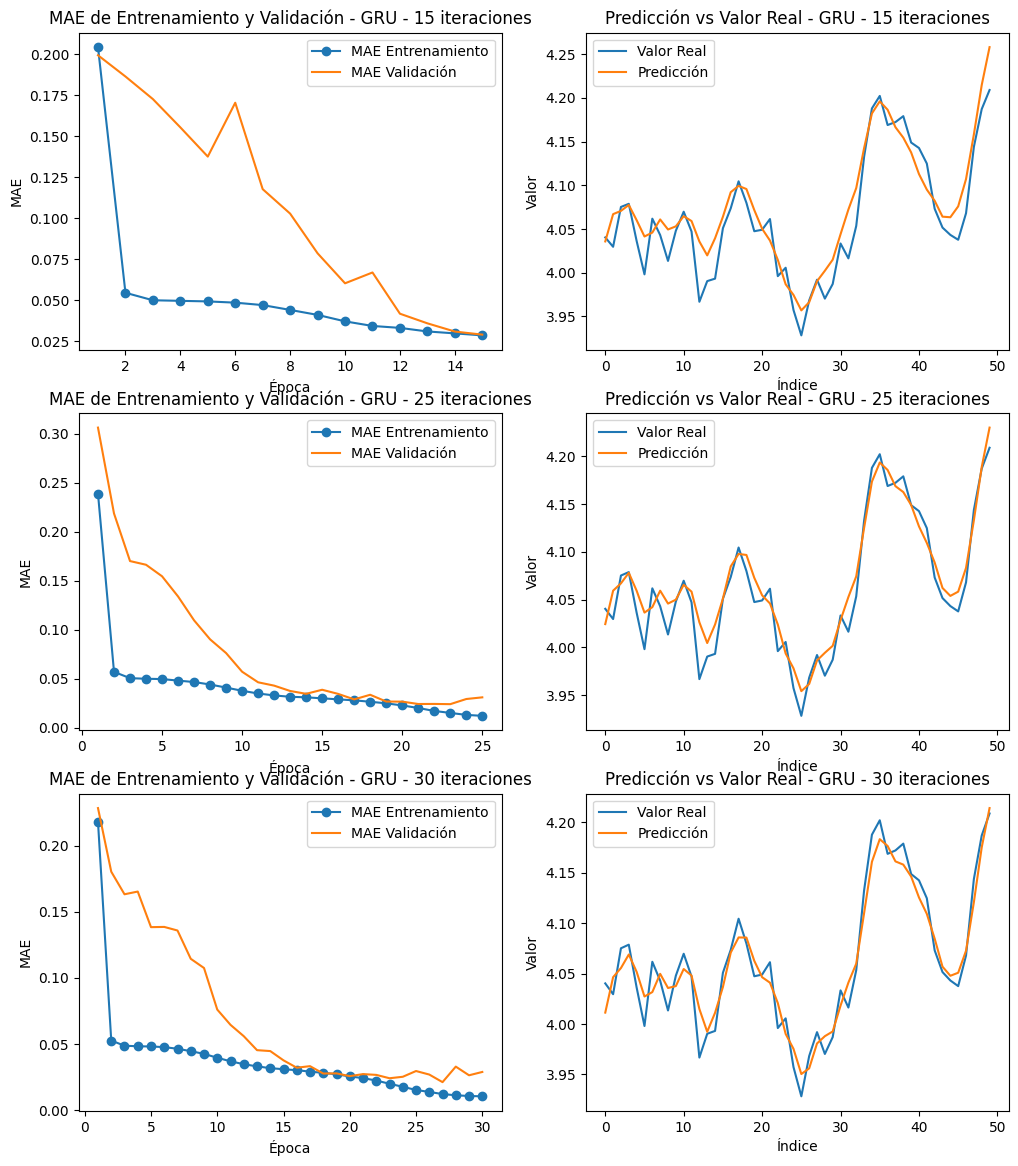

In [67]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

cantIteracionesGRU = [15, 25, 30]

for i, n in enumerate(cantIteracionesGRU):
  #Limpiar sesión
  tf.keras.backend.clear_session()
  
  #Crear el modelo 
  inputs = keras.Input(shape=(sequence_length, 1))
  x = layers.GRU(64)(inputs)
  outputs = layers.Dense(1)(x)
  modeloGRU = keras.Model(inputs, outputs)
  
  #Entrenar el modelo
  callbacksGRU = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
  ]
  modeloGRU.compile(optimizer="adam", loss="mse", metrics=["mae"])    
  
  historyGRU = modeloGRU.fit(
    datasetTrain,
    epochs=n,
    validation_data=datasetValidation,
    callbacks=callbacksGRU,
    verbose=0   
  )
  
  #Evaluar el modelo
  maeGRU = modeloGRU.evaluate(datasetTest, verbose=0)[1]
  predGRU = modeloGRU.predict(datasetTest)  
  graficaeMAE(historyGRU, f"MAE de Entrenamiento y Validación - GRU - {n} iteraciones", axes[i][0])
  graficarPrediccion(predGRU, y, f"Predicción vs Valor Real - GRU - {n} iteraciones", axes[i][1])

  print(f"MAE de prueba ({n} iteraciones): {maeGRU:.4f}")


### Pruebas habilitando y deshabilitando la opción de recurrent_dropout.  

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
MAE de prueba (0 recurrent_dropout): 0.8574
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
MAE de prueba (0.3 recurrent_dropout): 1.0535


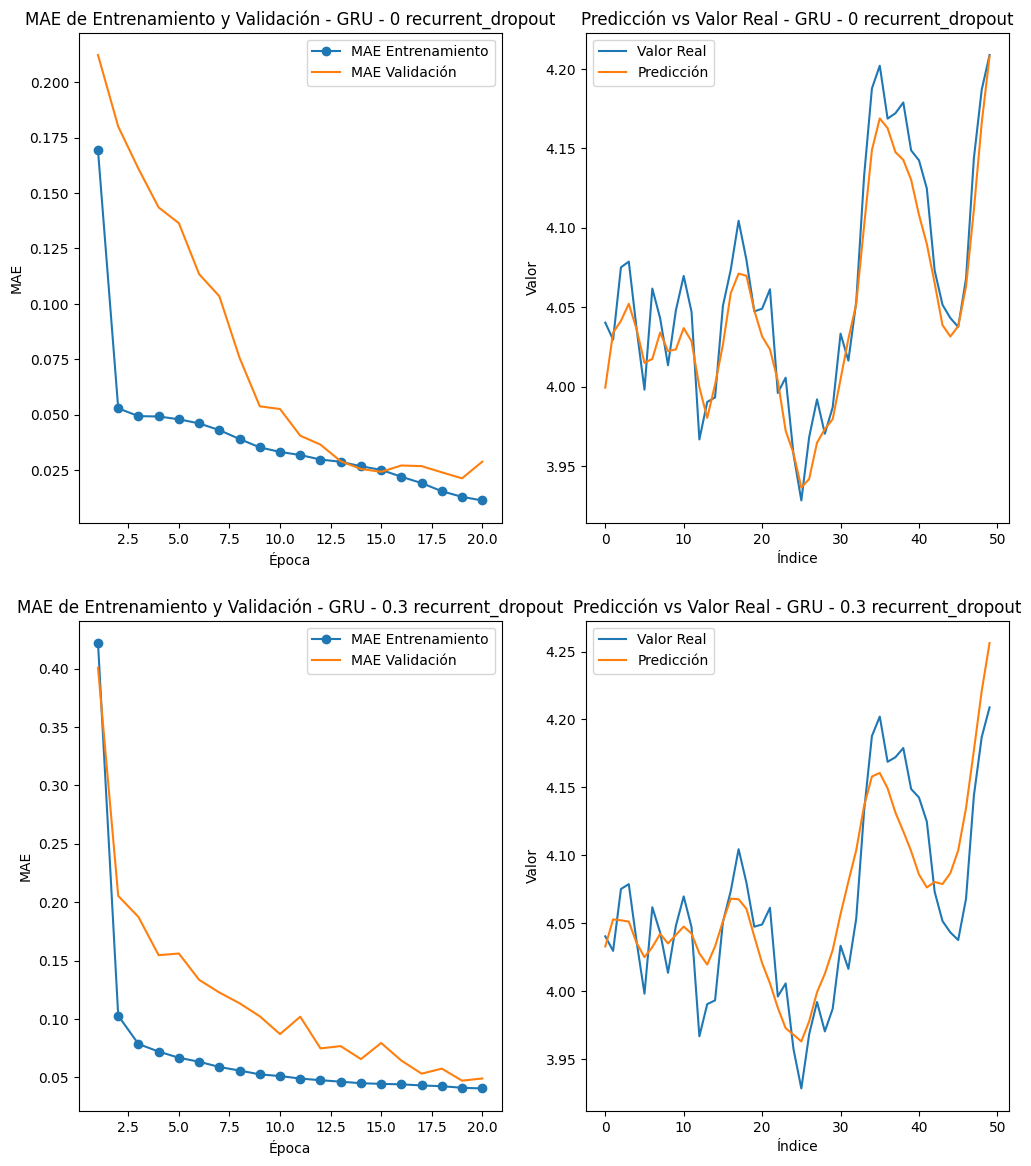

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(12, 14))

recurrentDropoutGRU = [0, 0.3]

for i, n in enumerate(recurrentDropoutGRU):
  #Limpiar sesión
  tf.keras.backend.clear_session()
  
  #Crear el modelo 
  inputs = keras.Input(shape=(sequence_length, 1))
  x = layers.GRU(64, recurrent_dropout=n)(inputs)
  outputs = layers.Dense(1)(x)
  modeloGRU = keras.Model(inputs, outputs)
  
  #Entrenar el modelo
  callbacksGRU = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
  ]
  modeloGRU.compile(optimizer="adam", loss="mse", metrics=["mae"])    
  
  historyGRU = modeloGRU.fit(
    datasetTrain,
    epochs=20,
    validation_data=datasetValidation,
    callbacks=callbacksGRU,
    verbose=0   
  )
  
  #Evaluar el modelo
  maeGRU = modeloGRU.evaluate(datasetTest, verbose=0)[1]
  predGRU = modeloGRU.predict(datasetTest)  
  graficaeMAE(historyGRU, f"MAE de Entrenamiento y Validación - GRU - {n} recurrent_dropout", axes[i][0])
  graficarPrediccion(predGRU, y, f"Predicción vs Valor Real - GRU - {n} recurrent_dropout", axes[i][1])

  print(f"MAE de prueba ({n} recurrent_dropout): {maeGRU:.4f}")


### Pruebas con diferente tamaño de batch

131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
MAE de prueba (tamaño de batch: 16): 0.5471
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
MAE de prueba (tamaño de batch: 32): 0.6367
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
MAE de prueba (tamaño de batch: 288): 0.7952


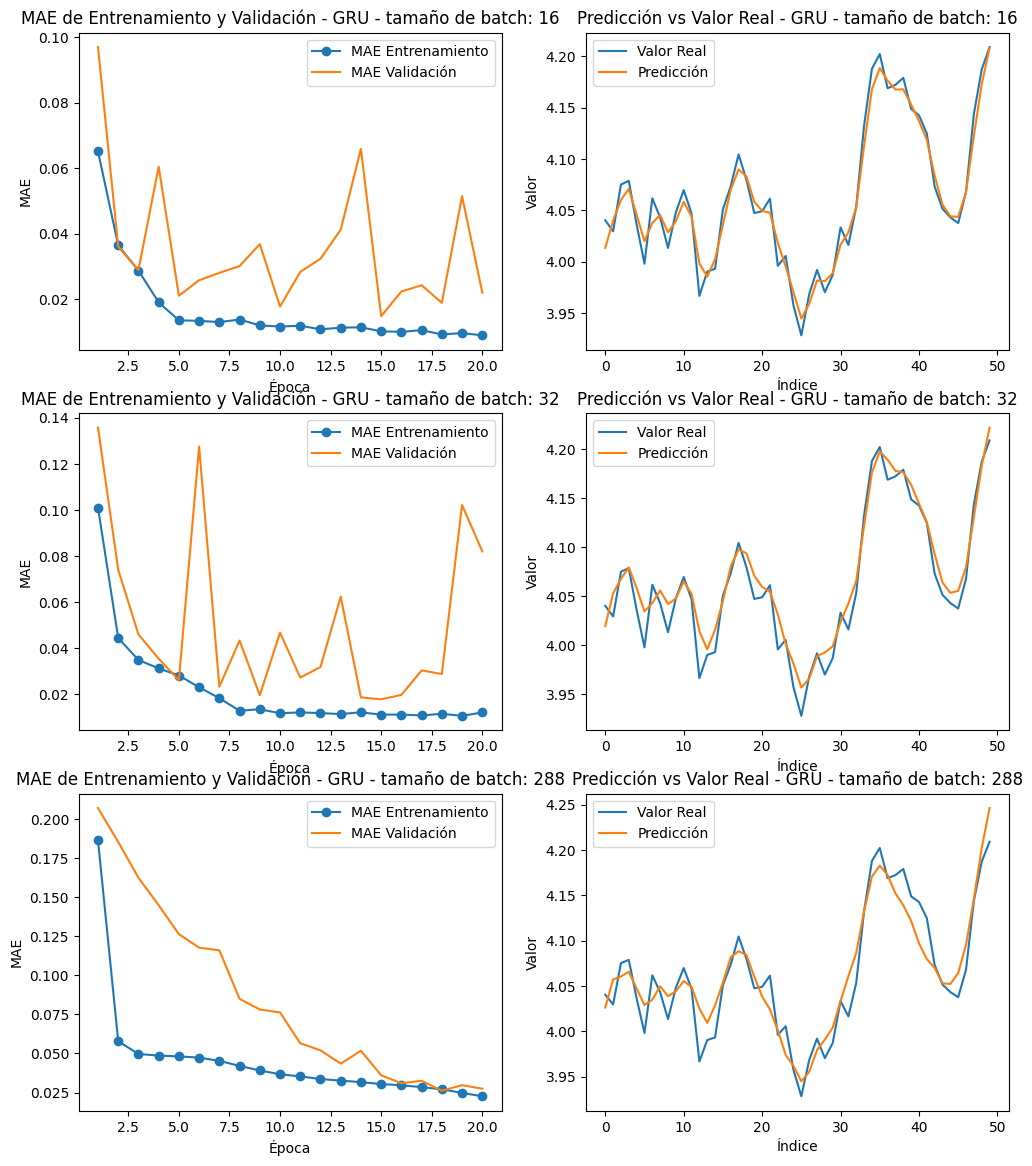

In [69]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

tamBatchGRU = [16, 32, 288]

for i, n in enumerate(tamBatchGRU):

  #Limpiar sesión
  tf.keras.backend.clear_session()

  #Definir datasets
  datasetTrain = keras.utils.timeseries_dataset_from_array(
    data = train2D[:-delay],
    targets=train2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=n,
    start_index=0
    )

  datasetValidation = keras.utils.timeseries_dataset_from_array(
    data = validation2D[:-delay],
    targets=validation2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=False,
    batch_size=n,
    start_index=0
    )

  datasetTest = keras.utils.timeseries_dataset_from_array(
    data = test2D[:-delay],
    targets=test2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=False,
    batch_size=n,
    start_index=0
    )
  
  #Crear el modelo 
  inputs = keras.Input(shape=(sequence_length, 1))
  x = layers.GRU(64)(inputs)
  outputs = layers.Dense(1)(x)
  modeloGRU = keras.Model(inputs, outputs)
  
  #Entrenar el modelo
  callbacksGRU = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
  ]
  modeloGRU.compile(optimizer="adam", loss="mse", metrics=["mae"])    
  
  historyGRU = modeloGRU.fit(
    datasetTrain,
    epochs=20,
    validation_data=datasetValidation,
    callbacks=callbacksGRU,
    verbose=0   
  )
  
  #Evaluar el modelo
  maeGRU = modeloGRU.evaluate(datasetTest, verbose=0)[1]
  predGRU = modeloGRU.predict(datasetTest)  
  graficaeMAE(historyGRU, f"MAE de Entrenamiento y Validación - GRU - tamaño de batch: {n}", axes[i][0])
  graficarPrediccion(predGRU, y, f"Predicción vs Valor Real - GRU - tamaño de batch: {n}", axes[i][1])

  print(f"MAE de prueba (tamaño de batch: {n}): {maeGRU:.4f}")


### Pruebas con diferente número de ventanas

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step
MAE de prueba (ventana de 5 días): 0.8375
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
MAE de prueba (ventana de 25 días): 1.2981
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
MAE de prueba (ventana de 35 días): 0.8742


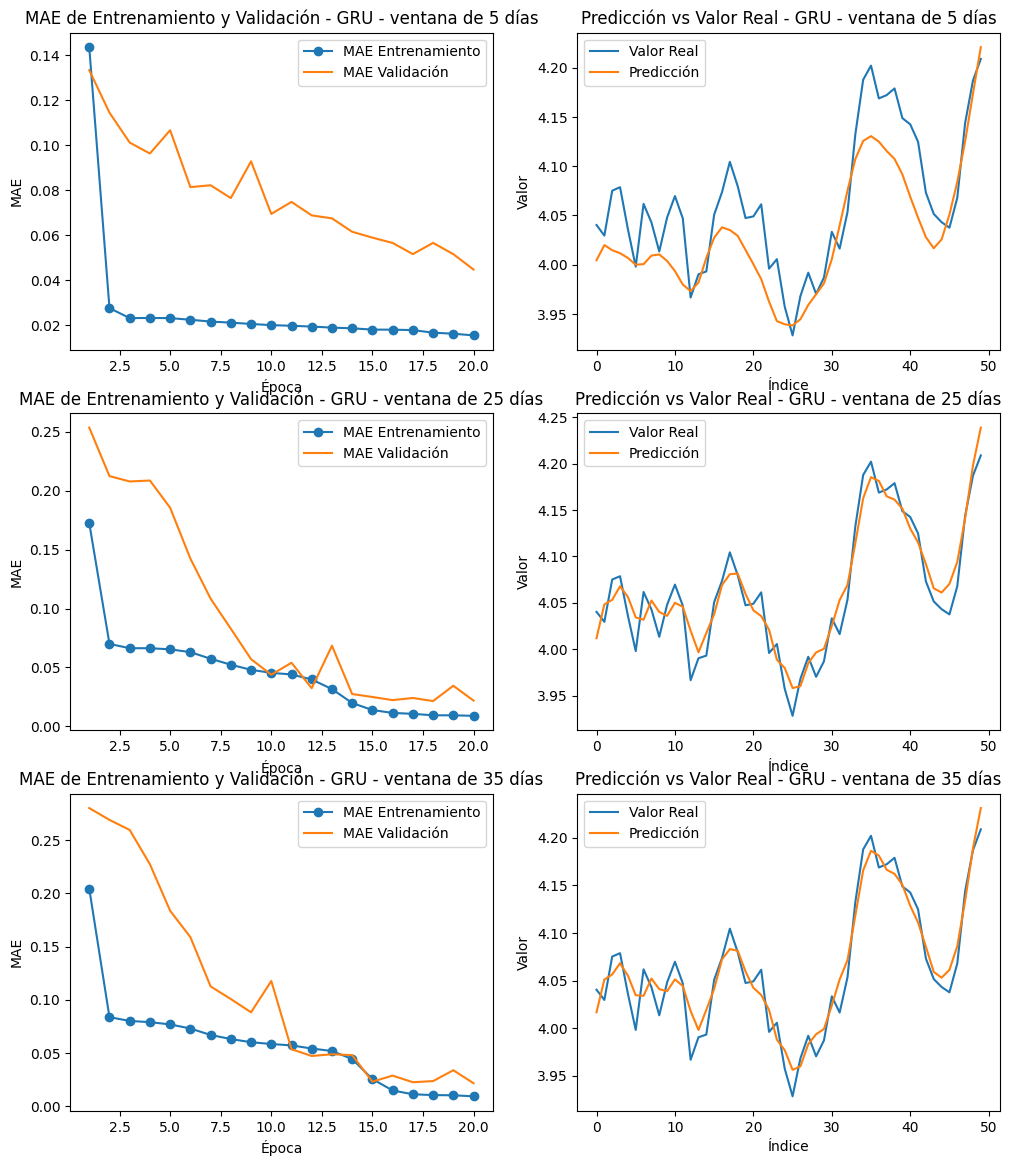

In [70]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

tamSequenceGRU = [5, 25, 35]

for i, n in enumerate(tamSequenceGRU):

  #Limpiar sesión
  tf.keras.backend.clear_session()

  #Definir datasets
  datasetTrain = keras.utils.timeseries_dataset_from_array(
    data = train2D[:-delay],
    targets=train2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=n,
    shuffle=True,
    batch_size=batch_size,
    start_index=0
    )

  datasetValidation = keras.utils.timeseries_dataset_from_array(
    data = validation2D[:-delay],
    targets=validation2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=n,
    shuffle=False,
    batch_size=batch_size,
    start_index=0
    )

  datasetTest = keras.utils.timeseries_dataset_from_array(
    data = test2D[:-delay],
    targets=test2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=n,
    shuffle=False,
    batch_size=batch_size,
    start_index=0
    )
  
  #Crear el modelo 
  inputs = keras.Input(shape=(n, 1))
  x = layers.GRU(64)(inputs)
  outputs = layers.Dense(1)(x)
  modeloGRU = keras.Model(inputs, outputs)
  
  #Entrenar el modelo
  callbacksGRU = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
  ]
  modeloGRU.compile(optimizer="adam", loss="mse", metrics=["mae"])    
  
  historyGRU = modeloGRU.fit(
    datasetTrain,
    epochs=20,
    validation_data=datasetValidation,
    callbacks=callbacksGRU,
    verbose=0   
  )
  
  #Evaluar el modelo
  maeGRU = modeloGRU.evaluate(datasetTest, verbose=0)[1]
  predGRU = modeloGRU.predict(datasetTest)  
  graficaeMAE(historyGRU, f"MAE de Entrenamiento y Validación - GRU - ventana de {n} días", axes[i][0])
  graficarPrediccion(predGRU, y, f"Predicción vs Valor Real - GRU - ventana de {n} días", axes[i][1])

  print(f"MAE de prueba (ventana de {n} días): {maeGRU:.4f}")


### Parámetros que permitieron obtener los mejores resultados

Cantidad de neuronas: 70

Épocas: 30

recurrent_dropout: 0

batch_size: 16

Sequence Length: 35 días

130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
MAE de prueba (mejor modelo): 0.3627


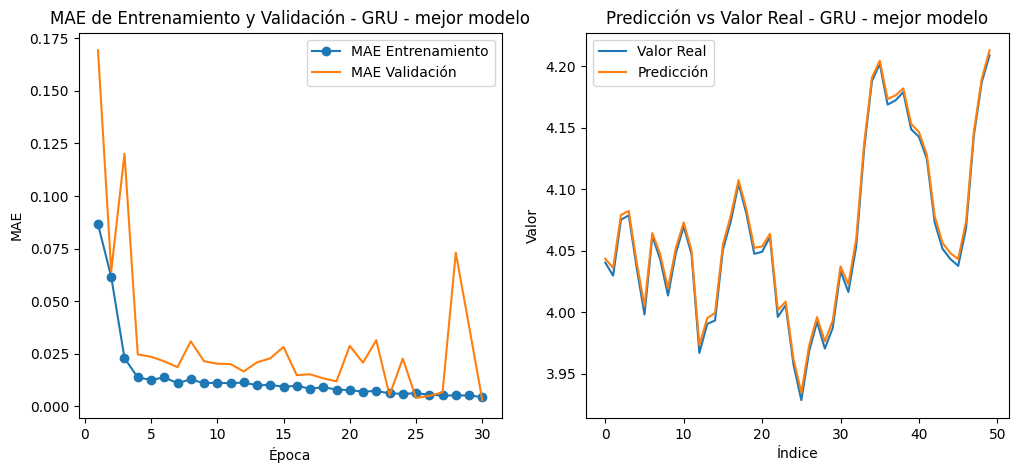

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Limpiar sesión
tf.keras.backend.clear_session()

#Definir datasets
datasetTrain = keras.utils.timeseries_dataset_from_array(
    data = train2D[:-delay],
    targets=train2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=35,
    shuffle=True,
    batch_size=16,
    start_index=0
)

datasetValidation = keras.utils.timeseries_dataset_from_array(
    data = validation2D[:-delay],
    targets=validation2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=35,
    shuffle=False,
    batch_size=16,
    start_index=0
)

datasetTest = keras.utils.timeseries_dataset_from_array(
    data = test2D[:-delay],
    targets=test2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=35,
    shuffle=False,
    batch_size=16,
    start_index=0
)
  
#Crear el modelo 
inputs = keras.Input(shape=(35, 1))
x = layers.GRU(70, recurrent_dropout=0)(inputs)
outputs = layers.Dense(1)(x)
modeloGRU = keras.Model(inputs, outputs)
  
#Entrenar el modelo
callbacksGRU = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]
modeloGRU.compile(optimizer="adam", loss="mse", metrics=["mae"])    
  
historyGRU = modeloGRU.fit(
    datasetTrain,
    epochs=30,
    validation_data=datasetValidation,
    callbacks=callbacksGRU,
    verbose=0   
)
  
#Evaluar el modelo
maeGRU = modeloGRU.evaluate(datasetTest, verbose=0)[1]
predGRU = modeloGRU.predict(datasetTest)  
graficaeMAE(historyGRU, f"MAE de Entrenamiento y Validación - GRU - mejor modelo", axes[0])
graficarPrediccion(predGRU, y, f"Predicción vs Valor Real - GRU - mejor modelo", axes[1])

print(f"MAE de prueba (mejor modelo): {maeGRU:.4f}")




## 4) LSTM con capas apiladas

In [33]:
def entrenarApilado(modelo, cantCapas):
  fig, axes = plt.subplots(1, 2, figsize=(12, 5))
  
  #Entrenar el modelo
  cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
  modelo.compile(optimizer="adam", loss="mse", metrics=["mae"])    

  history = modelo.fit(
    datasetTrainLSTM,
    epochs=50,
    validation_data=datasetValidationLSTM,
    callbacks=cb,
    verbose=0   
  )

  #Evaluar el modelo
  mae = modelo.evaluate(datasetTestLSTM, verbose=0)[1]
  y = np.concatenate([y for x, y in datasetTestLSTM], axis=0)
  pred = modelo.predict(datasetTestLSTM)  
  graficaeMAE(history, f"MAE de Entrenamiento y Validación - LSTM - {cantCapas} Capas Apiladas", axes[0])
  graficarPrediccion(pred, y, f"Predicción vs Valor Real - LSTM - {cantCapas} Capas Apiladas", axes[1])

  print(f"MAE de prueba - {cantCapas} Capas Apiladas): {mae:.4f}")

  plt.tight_layout()
  plt.show()

Sin capas apiladas - Una Sola Capa

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
MAE de prueba - 1 Capas Apiladas): 0.8596


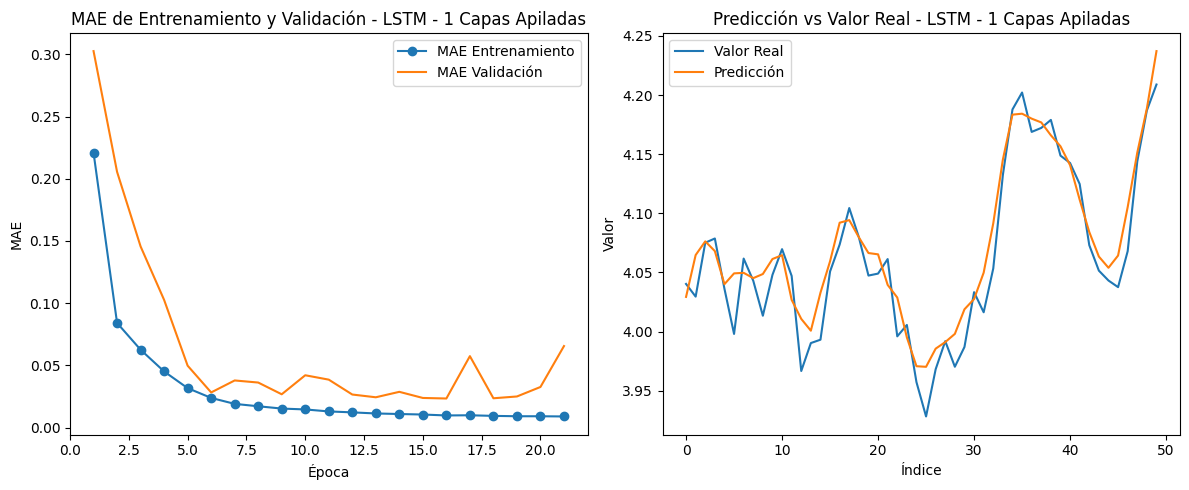

In [ ]:
inputs = keras.Input(shape=(3, 1))
x = layers.LSTM(15, recurrent_dropout=0.3)(inputs)
outputs = layers.Dense(1)(x)
modelo1 = keras.Model(inputs, outputs)

entrenarApilado(modelo1, 1)

Dos capas apiladas del mismo tamaño, solo la primera con recurrent dropout

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
MAE de prueba - 2 Capas Apiladas): 0.8929


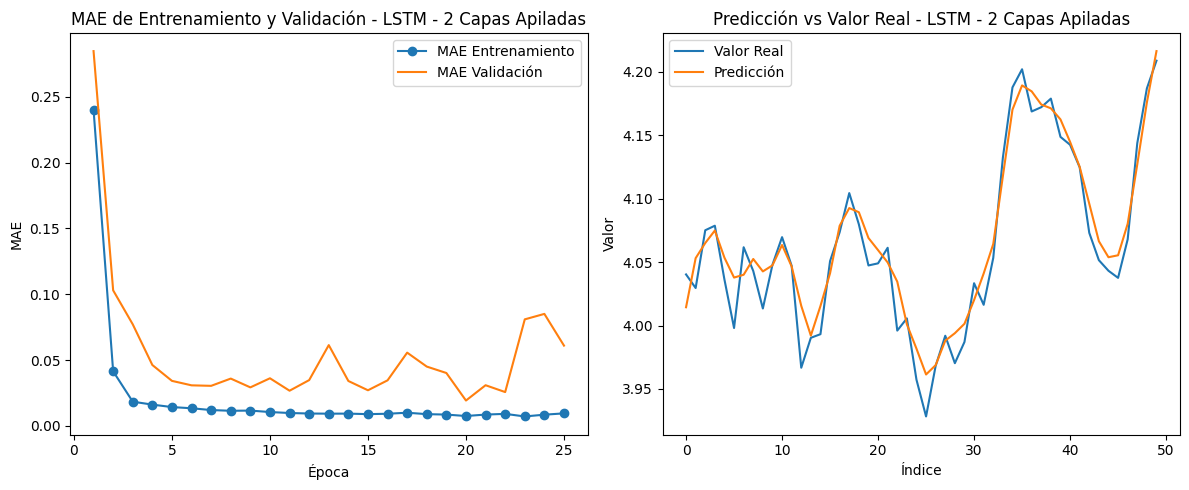

In [ ]:
inputs = keras.Input(shape=(3, 1))
x = layers.LSTM(15, recurrent_dropout=0.3, return_sequences=True)(inputs)
x = layers.LSTM(15)(x)
outputs = layers.Dense(1)(x)
modelo2 = keras.Model(inputs, outputs)

entrenarApilado(modelo2, 2)

Dos capas apiladas del mismo tamaño, ambas con recurrent dropout

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
MAE de prueba - 2 Capas Apiladas): 0.8274


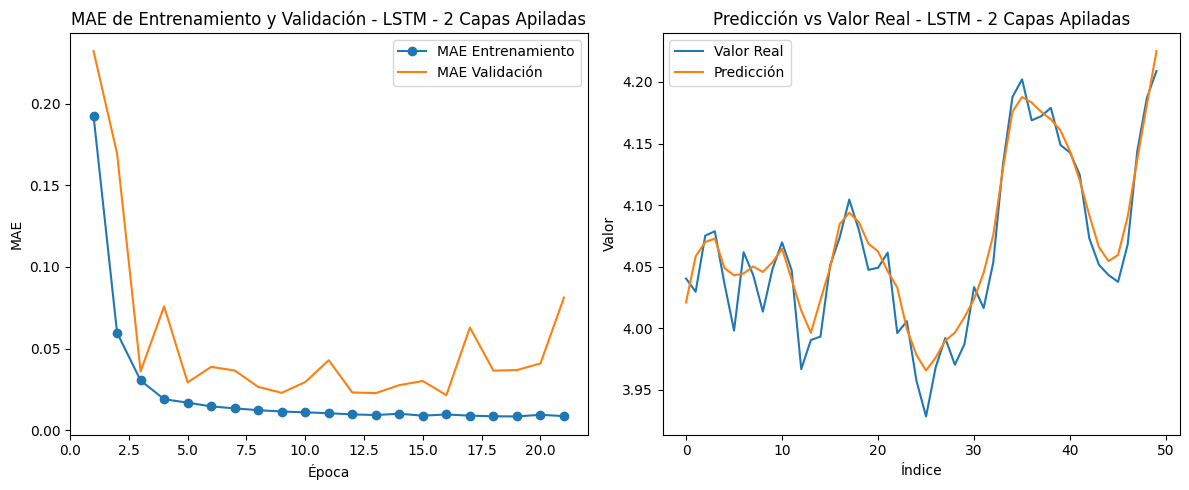

In [ ]:
inputs = keras.Input(shape=(3, 1))
x = layers.LSTM(15, recurrent_dropout=0.3, return_sequences=True)(inputs)
x = layers.LSTM(15, recurrent_dropout=0.3)(x)
outputs = layers.Dense(1)(x)
modelo3 = keras.Model(inputs, outputs)

entrenarApilado(modelo3, 2)

3 capas apiladas del mismo tamaño, solo la primera con dropout

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
MAE de prueba - 3 Capas Apiladas): 0.9333


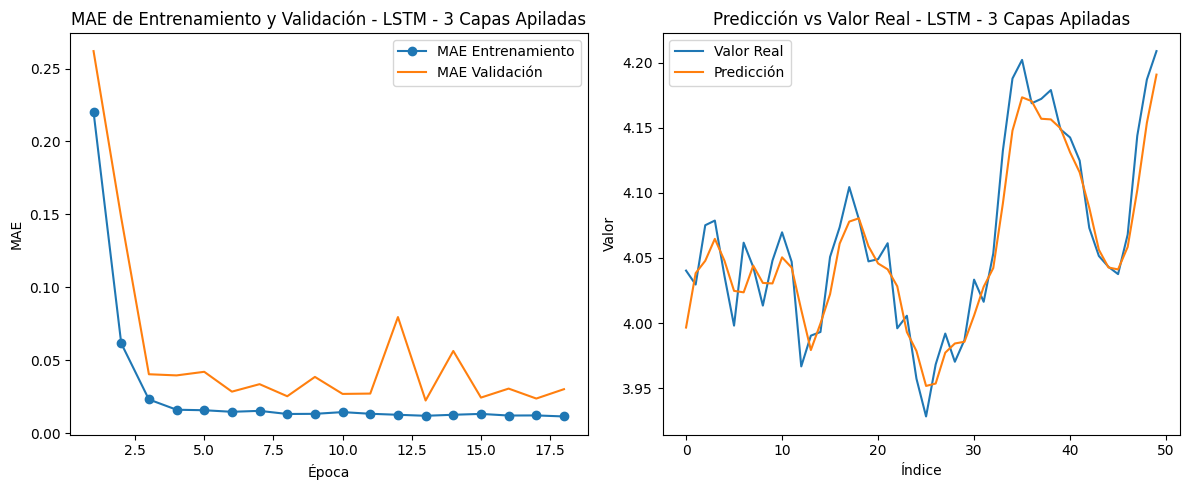

In [44]:
inputs = keras.Input(shape=(3, 1))
x = layers.LSTM(15, recurrent_dropout=0.3, return_sequences=True)(inputs)
x = layers.LSTM(15, return_sequences=True)(x)
x = layers.LSTM(15)(x)
outputs = layers.Dense(1)(x)
modelo4 = keras.Model(inputs, outputs)

entrenarApilado(modelo4, 3)

3 capas apiladas del mismo tamaño, todas con dropout

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
MAE de prueba - 3 Capas Apiladas): 1.1759


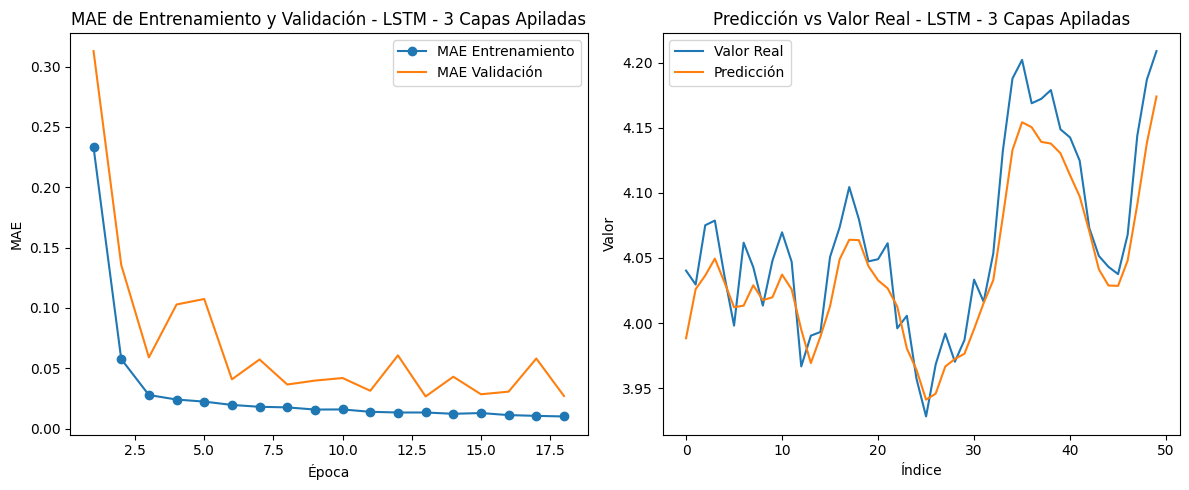

In [45]:
inputs = keras.Input(shape=(3, 1))
x = layers.LSTM(15, recurrent_dropout=0.3, return_sequences=True)(inputs)
x = layers.LSTM(15, recurrent_dropout=0.3, return_sequences=True)(x)
x = layers.LSTM(15, recurrent_dropout=0.3)(x)
outputs = layers.Dense(1)(x)
modelo5 = keras.Model(inputs, outputs)

entrenarApilado(modelo5, 3)

2 Capas apiladas (50 neuronas - 15 neuronas), ambas con dropout

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
MAE de prueba - 2 Capas Apiladas): 0.9863


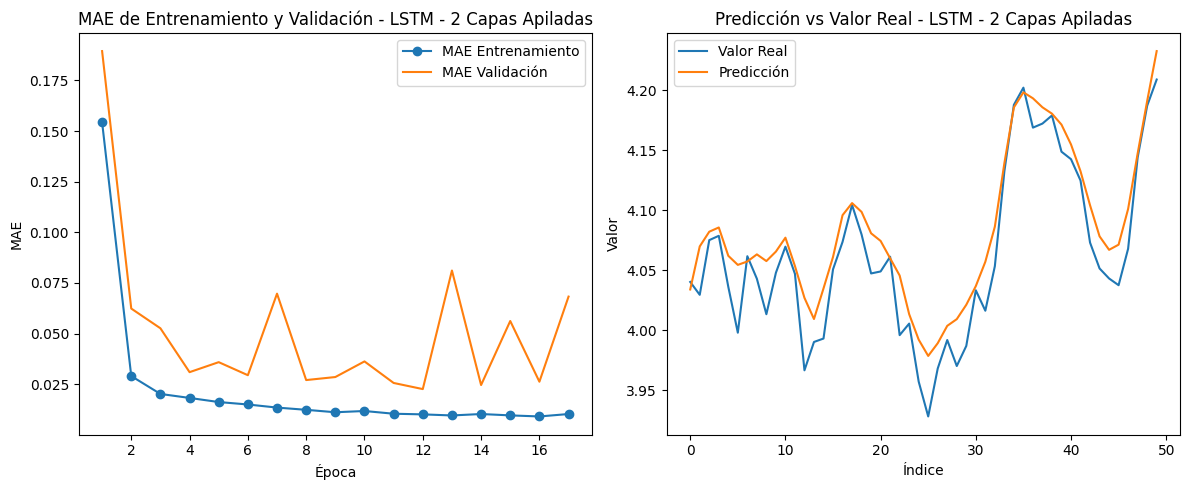

In [46]:
inputs = keras.Input(shape=(3, 1))
x = layers.LSTM(50, recurrent_dropout=0.3, return_sequences=True)(inputs)
x = layers.LSTM(15, recurrent_dropout=0.3)(x)
outputs = layers.Dense(1)(x)
modelo6 = keras.Model(inputs, outputs)

entrenarApilado(modelo6, 2)

2 Capas apiladas (15 neuronas - 5 neuronas), ambas con dropout

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
MAE de prueba - 2 Capas Apiladas): 1.3676


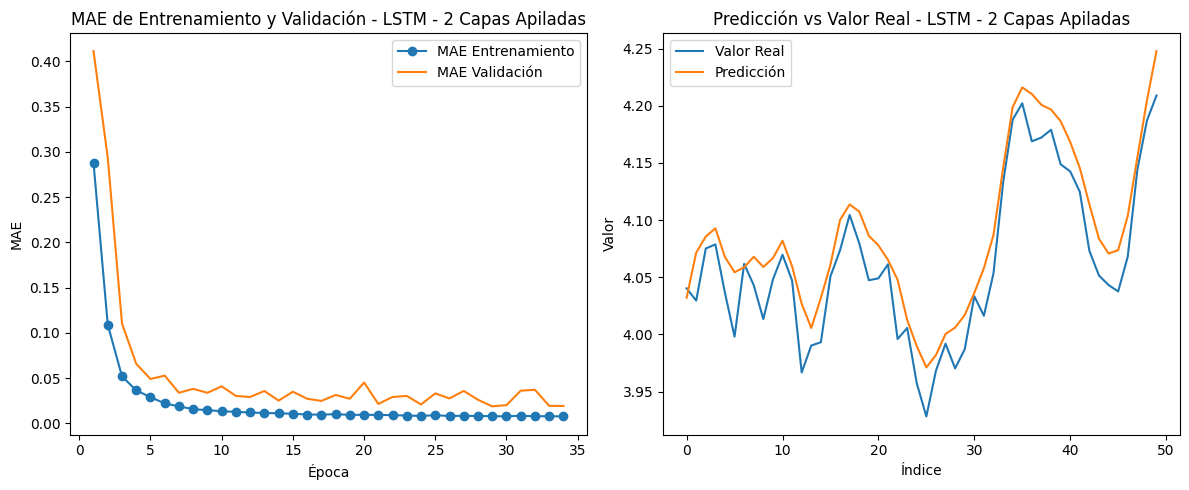

In [47]:
inputs = keras.Input(shape=(3, 1))
x = layers.LSTM(15, recurrent_dropout=0.3, return_sequences=True)(inputs)
x = layers.LSTM(5, recurrent_dropout=0.3)(x)
outputs = layers.Dense(1)(x)
modelo7 = keras.Model(inputs, outputs)

entrenarApilado(modelo7, 2)

## 4) GRU con capas apiladas

130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
MAE de prueba (mejor modelo): 1.4468


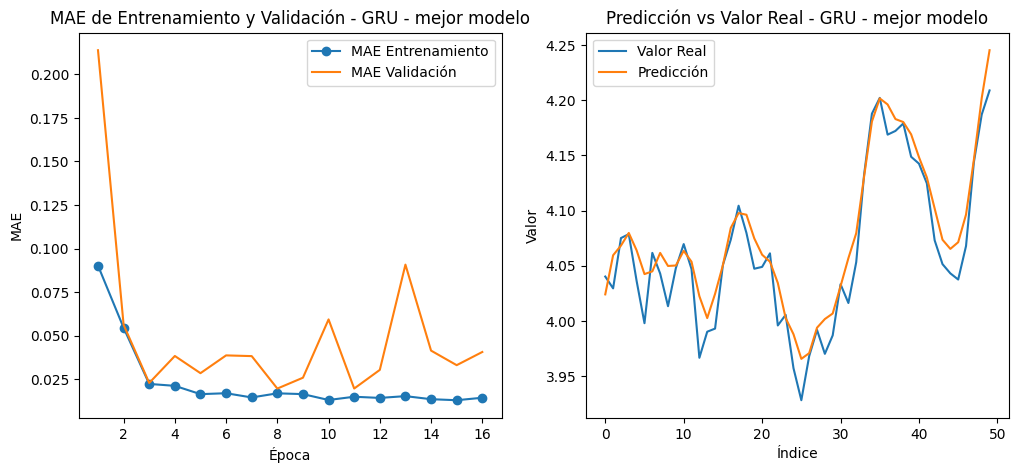

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Limpiar sesión
tf.keras.backend.clear_session()
  
#Crear el modelo con capas apiladas
inputs = keras.Input(shape=(35, 1))
x = layers.GRU(70, return_sequences=True, recurrent_dropout=0)(inputs)
x = layers.GRU(32, return_sequences=True, recurrent_dropout=0)(x)
x = layers.GRU(16, recurrent_dropout=0)(x)
outputs = layers.Dense(1)(x)
modeloGRU = keras.Model(inputs, outputs)
  
#Entrenar el modelo
callbacksGRU = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]
modeloGRU.compile(optimizer="adam", loss="mse", metrics=["mae"])    
  
historyGRU = modeloGRU.fit(
    datasetTrain,
    epochs=30,
    validation_data=datasetValidation,
    callbacks=callbacksGRU,
    verbose=0   
)
  
#Evaluar el modelo
maeGRU = modeloGRU.evaluate(datasetTest, verbose=0)[1]
predGRU = modeloGRU.predict(datasetTest)  
graficaeMAE(historyGRU, f"MAE de Entrenamiento y Validación - GRU - mejor modelo", axes[0])
graficarPrediccion(predGRU, y, f"Predicción vs Valor Real - GRU - mejor modelo", axes[1])

print(f"MAE de prueba (mejor modelo): {maeGRU:.4f}")